# Apollo Hospitals — Appointment No-Show & Patient Engagement Analysis

**Portfolio EDA | Python | Pandas | Matplotlib | Seaborn**

This notebook analyzes **75,000 appointments (2022–2024)** to understand appointment demand, no-show risk, patient engagement, financial performance, doctor utilisation, and service quality.

### Business rules used throughout
- **No-show rate** = No-Show ÷ (Completed + No-Show + Cancelled). `Scheduled` is excluded.
- **Quality metrics** (wait time, consultation duration, satisfaction, utilisation) are analysed only for `Completed` appointments.
- **Revenue metrics** are analysed only for `Completed` appointments, except **estimated no-show fee exposure**, which uses the listed consultation fee on No-Show appointments.
- `None` in chronic condition, membership type, insurance provider, and cancellation reason means **not applicable**, not missing.
- Doctor experience vs fee uses the **doctor dimension** (one row per doctor) to avoid appointment-level duplication.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Professional visual theme
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Consistent palette
NAVY = "#173F5F"
BLUE = "#20639B"
TEAL = "#3CAEA3"
GOLD = "#F6D55C"
ORANGE = "#ED553B"
RED = "#C0392B"
GREEN = "#2E8B57"
GREY = "#7F8C8D"

print("Libraries and visualization settings loaded.")

Libraries and visualization settings loaded.


In [2]:
# Portable file loader: works when CSVs are in the notebook folder or in ./data/
def find_project_file(*names):
    search_dirs = [Path.cwd(), Path.cwd() / "data", Path("/mnt/data")]
    for folder in search_dirs:
        for name in names:
            path = folder / name
            if path.exists():
                return path
    raise FileNotFoundError(
        f"Could not find any of: {names}. Put the CSV files beside the notebook or inside a 'data' folder."
    )

appointments_path = find_project_file(
    "apollo_appointments_fact.csv",
    "apollo_appointments_fact(1).csv"
)
doctors_path = find_project_file(
    "apollo_doctors_dim.csv",
    "apollo_doctors_dim(1).csv"
)

print("Appointments file:", appointments_path)
print("Doctors file:", doctors_path)

Appointments file: d:\PYTHON\Milestone Apollo Hospitals Project\apollo hospitals - Python Project\apollo_appointments_fact.csv
Doctors file: d:\PYTHON\Milestone Apollo Hospitals Project\apollo hospitals - Python Project\apollo_doctors_dim.csv


In [3]:
appointments = pd.read_csv(appointments_path)
doctors = pd.read_csv(doctors_path)

print(f"Appointments: {appointments.shape[0]:,} rows × {appointments.shape[1]} columns")
print(f"Doctors:      {doctors.shape[0]:,} rows × {doctors.shape[1]} columns")

display(appointments.head(3))
display(doctors.head(3))

Appointments: 75,000 rows × 52 columns
Doctors:      320 rows × 15 columns


,appointment_id,patient_id,doctor_id,appointment_date,appointment_day,appointment_day_of_week,appointment_month,appointment_quarter,appointment_year,appointment_hour,appointment_minute,time_slot,time_of_day,booking_date,booking_lead_days,booking_channel,appointment_type,specialty,city,state,hospital_name,patient_age,age_group,patient_gender,patient_city_tier,patient_chronic_condition,apollo_member,membership_type,reminder_type,reminders_sent,patient_prior_visits,patient_prior_no_shows,is_first_visit,repeat_visit,visit_reason,appointment_status,no_show,no_show_flag,cancellation_reason,consultation_fee,discount_pct,actual_fee_charged,insurance_coverage,insurance_provider,insurance_covered_amount,patient_out_of_pocket,revenue_realized,payment_mode,wait_time_minutes,consultation_duration_min,patient_satisfaction_score,doctor_utilization_pct
0,APPT5000001,PAT117608,DOC1035,2023-11-15,Wednesday,2,11,Q4,2023,15,30,15:30,Afternoon,2023-11-14,1,Apollo App,In-Clinic,Cardiology,Bengaluru,Karnataka,Apollo Clinic Jayanagar,76,Senior (60+),Female,1,NaN,No,NaN,SMS + WhatsApp,2,1,0,0,Yes,Joint Pain,Completed,No,0,NaN,2700,0,2700,No,NaN,0,2700,2700,UPI,11.00,40.00,4.80,84.20
1,APPT5000002,PAT128732,DOC1049,2023-03-13,Monday,0,3,Q1,2023,9,0,09:00,Morning,2023-03-05,8,Website,In-Clinic,Paediatrics,Pune,Maharashtra,Apollo Spectra Pune,6,Child (0-12),Male,1,NaN,No,NaN,SMS Only,1,1,0,0,Yes,Fever & Infection,Completed,No,0,NaN,1400,0,1400,No,NaN,0,1400,1400,UPI,21.00,18.00,4.10,64.50
2,APPT5000003,PAT137532,DOC1033,2022-02-07,Monday,0,2,Q1,2022,17,0,17:00,Evening,2022-02-07,0,Walk-In,In-Clinic,General Physician,Bengaluru,Karnataka,Apollo Spectra Koramangala,69,Senior (60+),Male,1,Hypothyroidism,No,NaN,SMS + WhatsApp + Call,3,1,0,0,Yes,Routine Checkup,Completed,No,0,NaN,600,0,600,No,NaN,0,600,600,Net Banking,6.00,6.00,5.00,75.60


,doctor_id,doctor_name,specialty,qualification,experience_years,city,state,hospital_name,consultation_fee,rating,total_reviews,available_days,avg_slot_duration_min,accepts_insurance,teleconsult_enabled
0,DOC1001,Dr. Deepa Sharma,Urology,"MBBS, MCh",12,Bengaluru,Karnataka,Apollo Hospital Bannerghatta,2300,4.40,1502,Mon-Fri,15,Yes,No
1,DOC1002,Dr. Venkatesan Khan,Paediatrics,"MBBS, MS, FRCS",25,Chandigarh,Punjab,Apollo Clinic Sector 8,1200,4.50,2453,Mon-Sat,10,Yes,Yes
2,DOC1003,Dr. Pradeep Menon,General Physician,"MBBS, DM",13,Mumbai,Maharashtra,Apollo Clinic Andheri,700,4.70,995,Mon-Wed-Fri-Sat,15,No,No


## 1. Data Preparation & Quality Checks

The goal here is to validate the dataset without cluttering the notebook with repetitive diagnostics. Structural nulls are handled according to the project data dictionary.

In [4]:
# Convert dates
appointments["appointment_date"] = pd.to_datetime(appointments["appointment_date"])
appointments["booking_date"] = pd.to_datetime(appointments["booking_date"])

# 'None' means "not applicable" for these categorical fields.
not_applicable_cols = [
    "patient_chronic_condition",
    "membership_type",
    "insurance_provider",
    "cancellation_reason",
]
appointments[not_applicable_cols] = appointments[not_applicable_cols].fillna("None")

# Compact data-quality summary
quality_summary = pd.DataFrame({
    "metric": [
        "Appointment rows",
        "Doctor rows",
        "Duplicate appointment IDs",
        "Duplicate doctor IDs in dimension",
        "Booking date after appointment date",
        "Appointment doctor IDs missing from dimension",
    ],
    "value": [
        len(appointments),
        len(doctors),
        appointments["appointment_id"].duplicated().sum(),
        doctors["doctor_id"].duplicated().sum(),
        (appointments["booking_date"] > appointments["appointment_date"]).sum(),
        len(set(appointments["doctor_id"]) - set(doctors["doctor_id"])),
    ],
})

display(quality_summary)

,metric,value
0,Appointment rows,75000
1,Doctor rows,320
2,Duplicate appointment IDs,0
3,Duplicate doctor IDs in dimension,0
4,Booking date after appointment date,0
5,Appointment doctor IDs missing from dimension,0


In [5]:
# Validate derived booking lead days
calculated_lead_days = (
    appointments["appointment_date"] - appointments["booking_date"]
).dt.days

lead_mismatches = (calculated_lead_days != appointments["booking_lead_days"]).sum()

# Validate expected structural nulls / zeros
quality_cols = [
    "wait_time_minutes",
    "consultation_duration_min",
    "patient_satisfaction_score",
    "doctor_utilization_pct",
]
financial_cols = [
    "actual_fee_charged",
    "insurance_covered_amount",
    "patient_out_of_pocket",
    "revenue_realized",
]

non_completed = appointments["appointment_status"].ne("Completed")

validation = pd.DataFrame({
    "check": [
        "Booking lead-day mismatches",
        "Quality values incorrectly populated on non-Completed rows",
        "Financial values non-zero on non-Completed rows",
    ],
    "issues_found": [
        int(lead_mismatches),
        int(appointments.loc[non_completed, quality_cols].notna().sum().sum()),
        int((appointments.loc[non_completed, financial_cols] != 0).sum().sum()),
    ],
})
display(validation)

,check,issues_found
0,Booking lead-day mismatches,0
1,Quality values incorrectly populated on non-Co...,0
2,Financial values non-zero on non-Completed rows,0


In [6]:
# Merge only doctor-level attributes needed for downstream analysis.
doctor_attrs = doctors[[
    "doctor_id",
    "doctor_name",
    "experience_years",
    "rating",
    "total_reviews",
    "avg_slot_duration_min",
    "accepts_insurance",
    "teleconsult_enabled",
]].copy()

df = appointments.merge(
    doctor_attrs,
    on="doctor_id",
    how="left",
    validate="many_to_one"
)

# Analysis subsets
ELIGIBLE_STATUSES = ["Completed", "No-Show", "Cancelled"]
eligible = df[df["appointment_status"].isin(ELIGIBLE_STATUSES)].copy()
completed = df[df["appointment_status"].eq("Completed")].copy()

print(f"Merged dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Eligible for no-show denominator: {len(eligible):,}")
print(f"Completed appointments: {len(completed):,}")

Merged dataset: 75,000 rows × 59 columns
Eligible for no-show denominator: 72,652
Completed appointments: 55,275


In [7]:
# Reusable helpers keep calculations consistent and avoid repeated code.

def no_show_rate_table(data, group_col):
    result = (
        data.groupby(group_col, dropna=False, observed=True)
        .agg(
            eligible_appointments=("appointment_id", "size"),
            no_shows=("appointment_status", lambda s: s.eq("No-Show").sum()),
        )
        .reset_index()
    )
    result["no_show_rate_pct"] = (
        result["no_shows"] / result["eligible_appointments"] * 100
    )
    return result.sort_values("no_show_rate_pct", ascending=False)


def add_bar_labels(ax, suffix="", decimals=1):
    for container in ax.containers:
        labels = [
            f"{bar.get_width():,.{decimals}f}{suffix}"
            if bar.get_width() >= 0 else ""
            for bar in container
        ]
        ax.bar_label(container, labels=labels, padding=4, fontsize=9)


def plot_rate_bar(table, category, title, overall_rate=None, color=BLUE):
    plot_data = table.sort_values("no_show_rate_pct", ascending=True)
    fig, ax = plt.subplots(figsize=(11, max(4.8, 0.42 * len(plot_data) + 1.8)))
    sns.barplot(data=plot_data, x="no_show_rate_pct", y=category, color=color, ax=ax)

    if overall_rate is not None:
        ax.axvline(overall_rate, linestyle="--", linewidth=1.5, color=RED,
                   label=f"Overall: {overall_rate:.2f}%")
        ax.legend(loc="lower right")

    ax.set(title=title, xlabel="No-Show Rate (%)", ylabel="")
    add_bar_labels(ax, suffix="%")
    ax.grid(axis="x", alpha=0.20)
    ax.grid(axis="y", visible=False)
    plt.tight_layout()
    plt.show()


def format_inr(value):
    if value >= 1e7:
        return f"₹{value / 1e7:,.2f} Cr"
    if value >= 1e5:
        return f"₹{value / 1e5:,.2f} L"
    return f"₹{value:,.0f}"

In [8]:
# Core project KPIs
status_counts = df["appointment_status"].value_counts()
overall_no_show_rate = eligible["appointment_status"].eq("No-Show").mean() * 100
gross_no_show_fee_exposure = df.loc[
    df["appointment_status"].eq("No-Show"), "consultation_fee"
].sum()
realized_revenue = completed["revenue_realized"].sum()

kpis = pd.DataFrame({
    "KPI": [
        "Total appointments",
        "Completed",
        "No-Shows",
        "Cancelled",
        "Scheduled",
        "Overall no-show rate",
        "Realized revenue (Completed)",
        "Estimated gross fee exposure (No-Shows)",
    ],
    "Value": [
        f"{len(df):,}",
        f"{status_counts.get('Completed', 0):,}",
        f"{status_counts.get('No-Show', 0):,}",
        f"{status_counts.get('Cancelled', 0):,}",
        f"{status_counts.get('Scheduled', 0):,}",
        f"{overall_no_show_rate:.2f}%",
        format_inr(realized_revenue),
        format_inr(gross_no_show_fee_exposure),
    ]
})
display(kpis)

,KPI,Value
0,Total appointments,"75,000"
1,Completed,"55,275"
2,No-Shows,"11,584"
3,Cancelled,"5,793"
4,Scheduled,"2,348"
5,Overall no-show rate,15.94%
6,Realized revenue (Completed),₹7.39 Cr
7,Estimated gross fee exposure (No-Shows),₹1.97 Cr


## 2. Business Overview
### Appointment volume, outcome split, and booking-channel mix

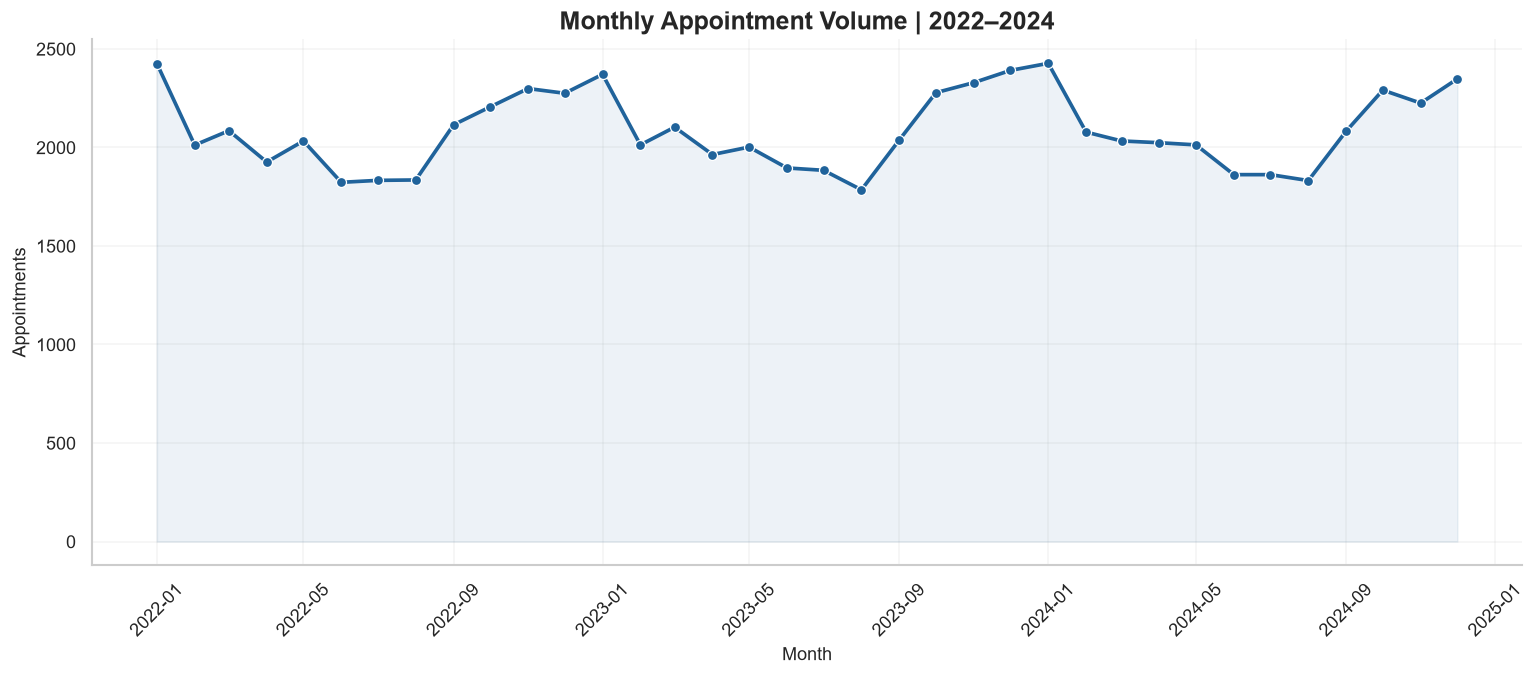

,month,appointments
30,2024-07-01,1862
31,2024-08-01,1832
32,2024-09-01,2083
33,2024-10-01,2291
34,2024-11-01,2225
35,2024-12-01,2348


In [9]:
monthly_appointments = (
    df.assign(month=df["appointment_date"].dt.to_period("M").dt.to_timestamp())
      .groupby("month")
      .size()
      .reset_index(name="appointments")
)

fig, ax = plt.subplots(figsize=(13, 5.8))
sns.lineplot(
    data=monthly_appointments,
    x="month",
    y="appointments",
    marker="o",
    color=BLUE,
    linewidth=2.2,
    ax=ax,
)
ax.fill_between(
    monthly_appointments["month"],
    monthly_appointments["appointments"],
    alpha=0.08,
    color=BLUE,
)
ax.set(
    title="Monthly Appointment Volume | 2022–2024",
    xlabel="Month",
    ylabel="Appointments",
)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.20)
plt.tight_layout()
plt.show()

display(monthly_appointments.tail(6))

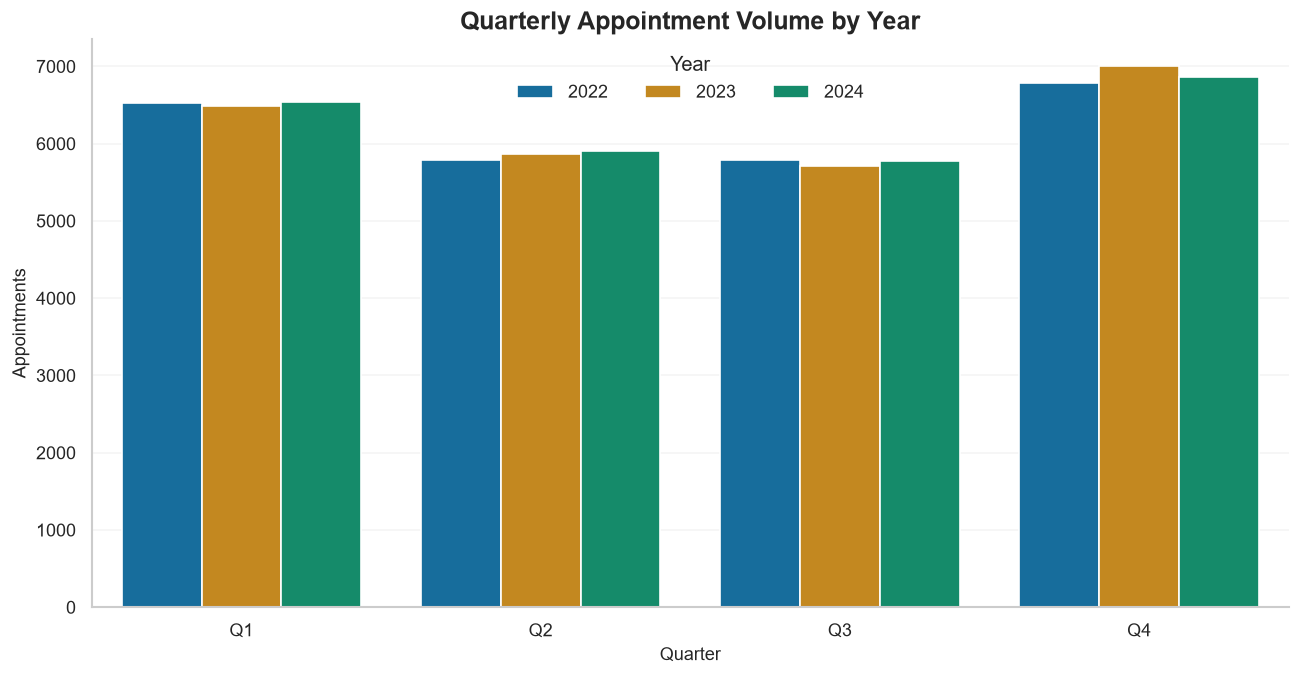

,appointment_year,appointment_quarter,appointments,quarter
0,2022,Q1,6523,Q1
1,2022,Q2,5782,Q2
2,2022,Q3,5783,Q3
3,2022,Q4,6780,Q4
4,2023,Q1,6487,Q1
5,2023,Q2,5862,Q2
6,2023,Q3,5707,Q3
7,2023,Q4,6998,Q4
8,2024,Q1,6538,Q1
9,2024,Q2,5899,Q2


In [42]:
quarterly_appointments = (
    df.groupby(["appointment_year", "appointment_quarter"])
      .size()
      .reset_index(name="appointments")
)

quarterly_appointments["quarter"] = pd.Categorical(
    quarterly_appointments["appointment_quarter"],
    categories=["Q1", "Q2", "Q3", "Q4"],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(11, 5.8))

sns.barplot(
    data=quarterly_appointments,
    x="quarter",
    y="appointments",
    hue="appointment_year",
    palette="colorblind",
    ax=ax,
)

ax.set(
    title="Quarterly Appointment Volume by Year",
    xlabel="Quarter",
    ylabel="Appointments"
)

ax.legend(title="Year", ncol=3)
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

display(quarterly_appointments)

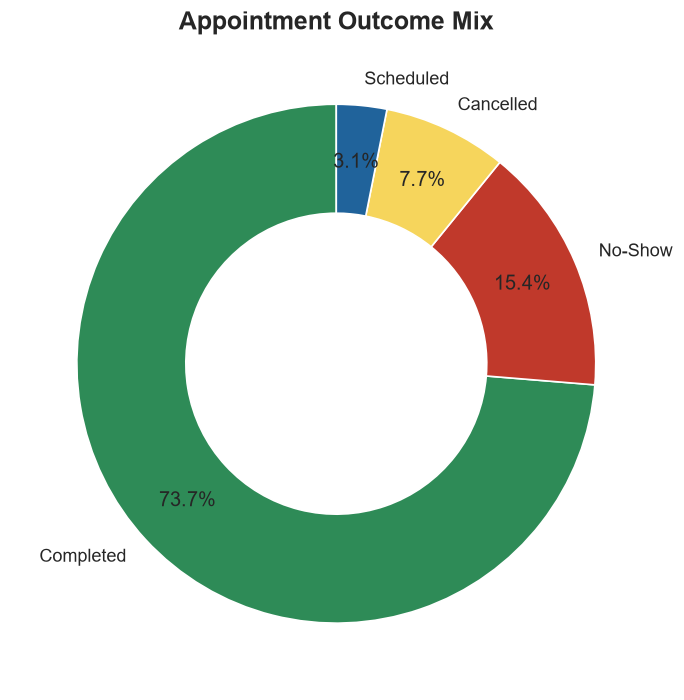

,appointment_status,appointments,share_pct
0,Completed,55275,73.70
1,No-Show,11584,15.45
2,Cancelled,5793,7.72
3,Scheduled,2348,3.13


In [11]:
outcome_summary = (
    df["appointment_status"]
    .value_counts()
    .rename_axis("appointment_status")
    .reset_index(name="appointments")
)
outcome_summary["share_pct"] = outcome_summary["appointments"] / len(df) * 100

status_order = ["Completed", "No-Show", "Cancelled", "Scheduled"]
outcome_summary["appointment_status"] = pd.Categorical(
    outcome_summary["appointment_status"], categories=status_order, ordered=True
)
outcome_summary = outcome_summary.sort_values("appointment_status")

status_colors = [GREEN, RED, GOLD, BLUE]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, _, autotexts = ax.pie(
    outcome_summary["appointments"],
    labels=outcome_summary["appointment_status"],
    autopct="%1.1f%%",
    startangle=90,
    colors=status_colors,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
    pctdistance=0.78,
)
ax.set_title("Appointment Outcome Mix")
plt.tight_layout()
plt.show()

display(outcome_summary)

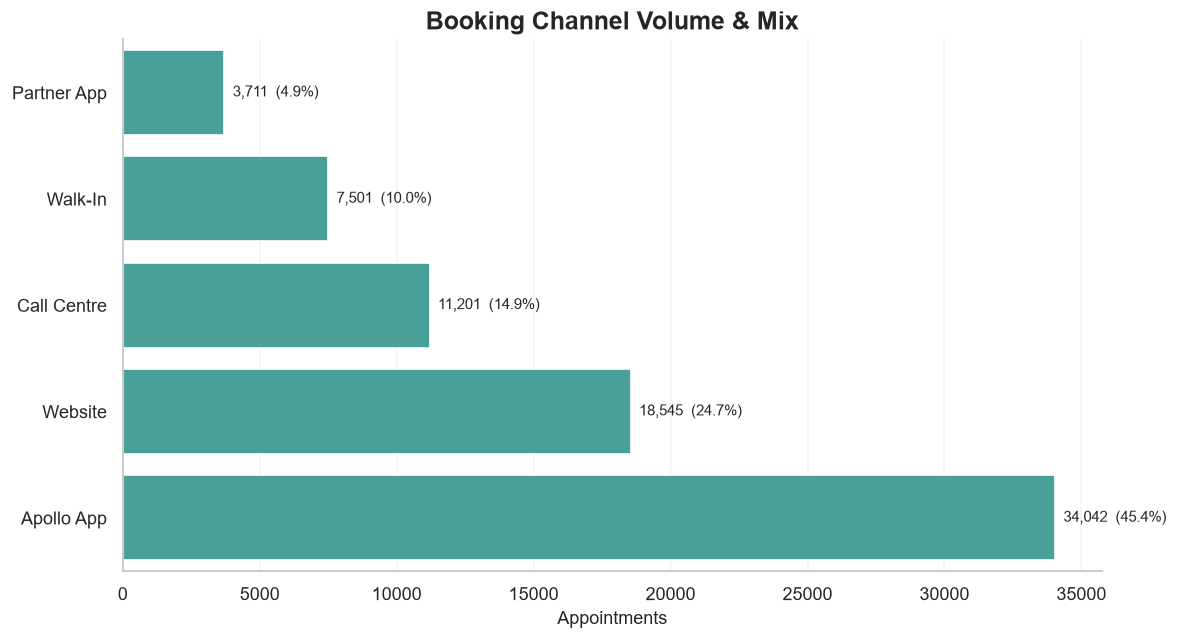

,booking_channel,appointments,share_pct
0,Apollo App,34042,45.39
1,Website,18545,24.73
2,Call Centre,11201,14.93
3,Walk-In,7501,10.00
4,Partner App,3711,4.95


In [12]:
channel_mix = (
    df["booking_channel"]
    .value_counts()
    .rename_axis("booking_channel")
    .reset_index(name="appointments")
)
channel_mix["share_pct"] = channel_mix["appointments"] / len(df) * 100
channel_mix = channel_mix.sort_values("appointments", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=channel_mix, x="appointments", y="booking_channel", color=TEAL, ax=ax)
ax.set(title="Booking Channel Volume & Mix", xlabel="Appointments", ylabel="")
for container in ax.containers:
    labels = [
        f"{int(bar.get_width()):,}  ({row:.1f}%)"
        for bar, row in zip(container, channel_mix["share_pct"])
    ]
    ax.bar_label(container, labels=labels, padding=5, fontsize=9)
ax.grid(axis="x", alpha=0.20)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

display(channel_mix.sort_values("appointments", ascending=False))

## 3. No-Show Analysis
All rates below use the business-defined denominator: **Completed + No-Show + Cancelled**.

,specialty,eligible_appointments,no_shows,no_show_rate_pct
11,Psychiatry,2900,711,24.52
1,Dermatology,7566,1608,21.25
2,ENT,5211,988,18.96
3,Endocrinology,2024,355,17.54
8,Ophthalmology,3103,503,16.21
5,General Physician,19654,3049,15.51
12,Pulmonology,2549,394,15.46
9,Orthopaedics,5419,810,14.95
4,Gastroenterology,2527,377,14.92
13,Urology,2222,320,14.40


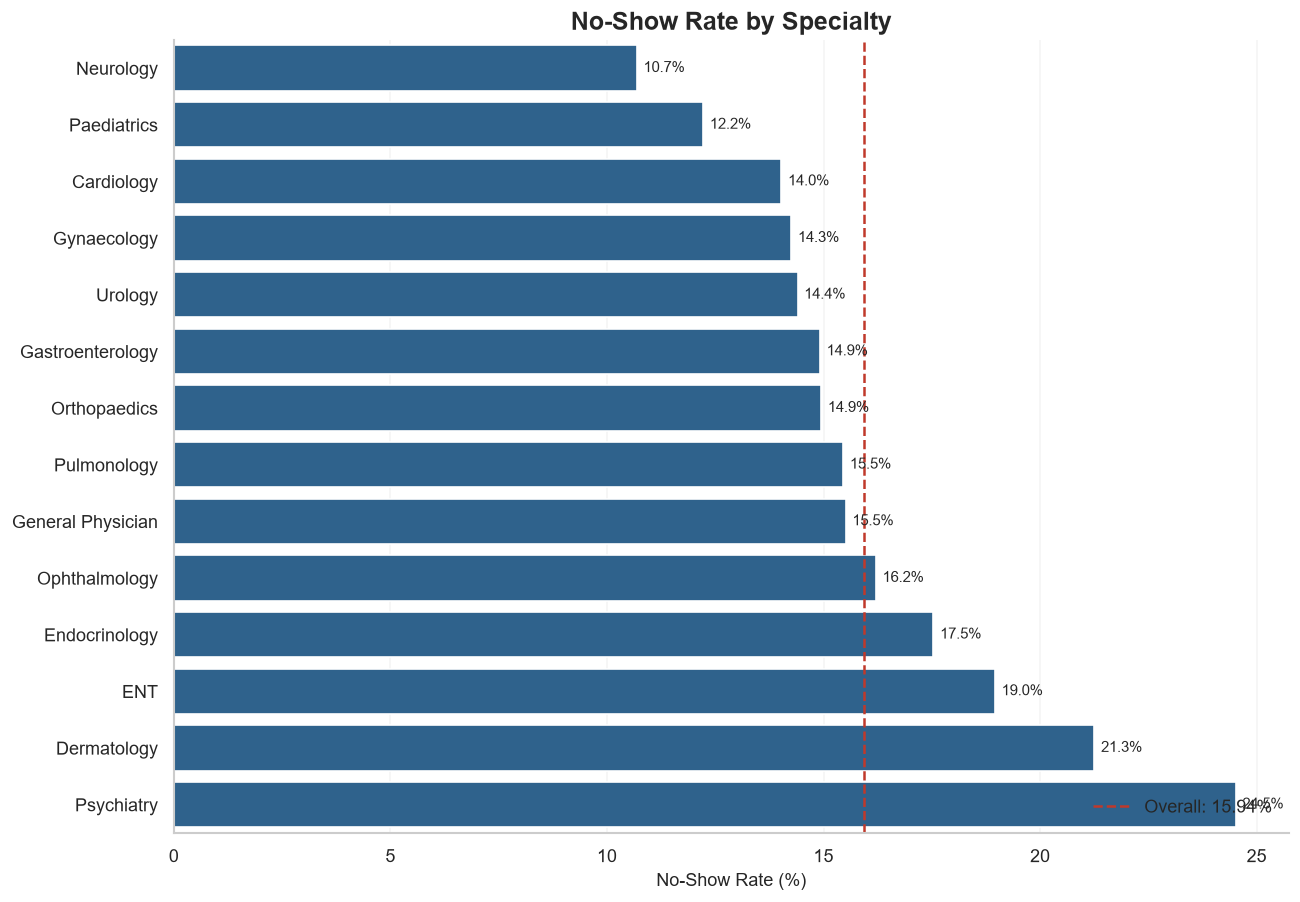

In [13]:
specialty_no_show = no_show_rate_table(eligible, "specialty")
city_no_show = no_show_rate_table(eligible, "city")

display(specialty_no_show)
plot_rate_bar(
    specialty_no_show,
    "specialty",
    "No-Show Rate by Specialty",
    overall_rate=overall_no_show_rate,
    color=BLUE,
)

,city,eligible_appointments,no_shows,no_show_rate_pct
12,Lucknow,3001,516,17.19
13,Mumbai,9734,1659,17.04
6,Delhi,10404,1754,16.86
2,Bhopal,2001,336,16.79
11,Kolkata,5701,933,16.37
10,Kochi,2690,438,16.28
0,Ahmedabad,3468,561,16.18
9,Jaipur,2653,429,16.17
7,Hyderabad,7229,1160,16.05
1,Bengaluru,8343,1287,15.43


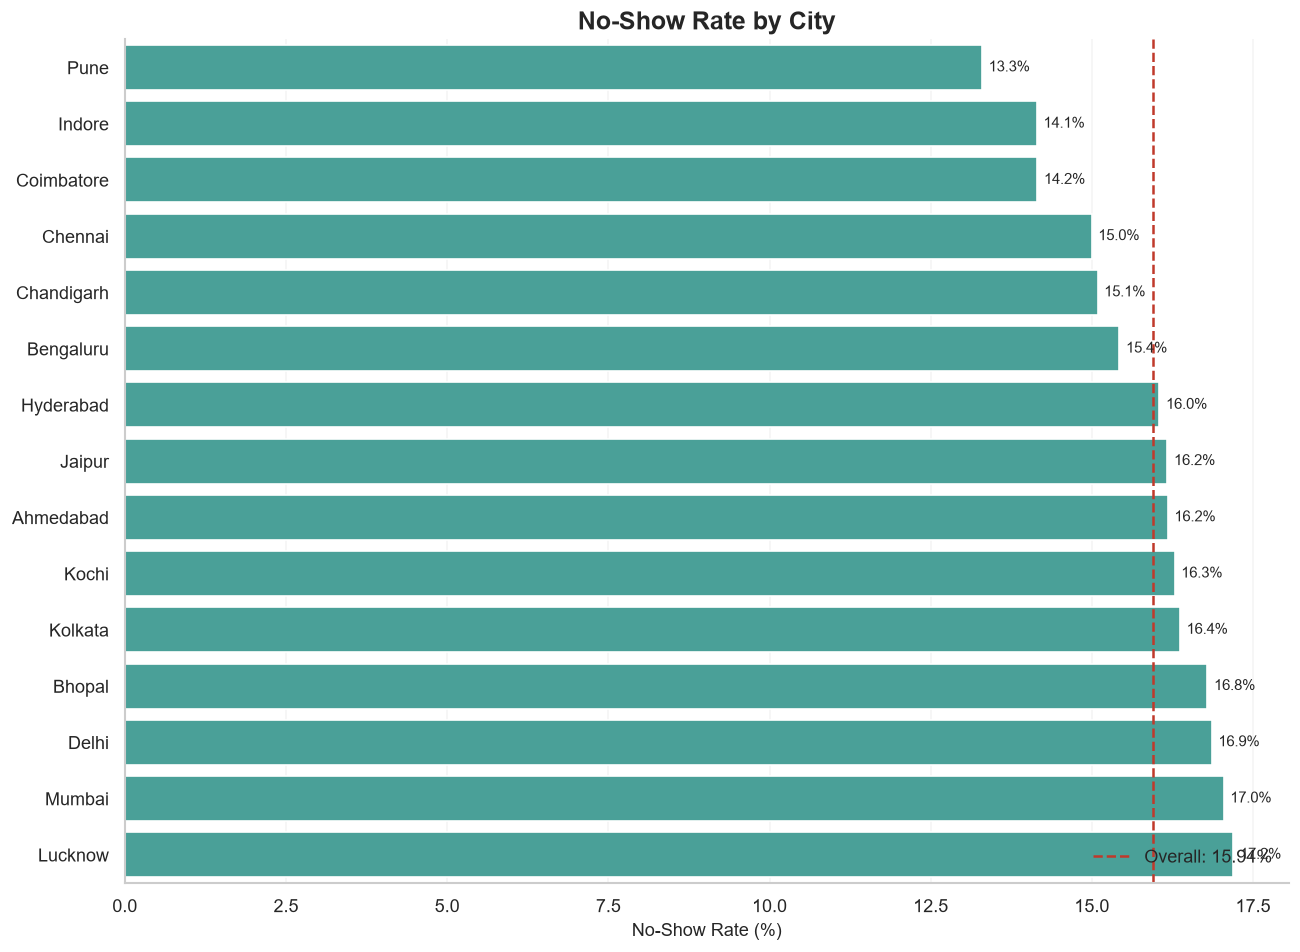

In [14]:
display(city_no_show)
plot_rate_bar(
    city_no_show,
    "city",
    "No-Show Rate by City",
    overall_rate=overall_no_show_rate,
    color=TEAL,
)

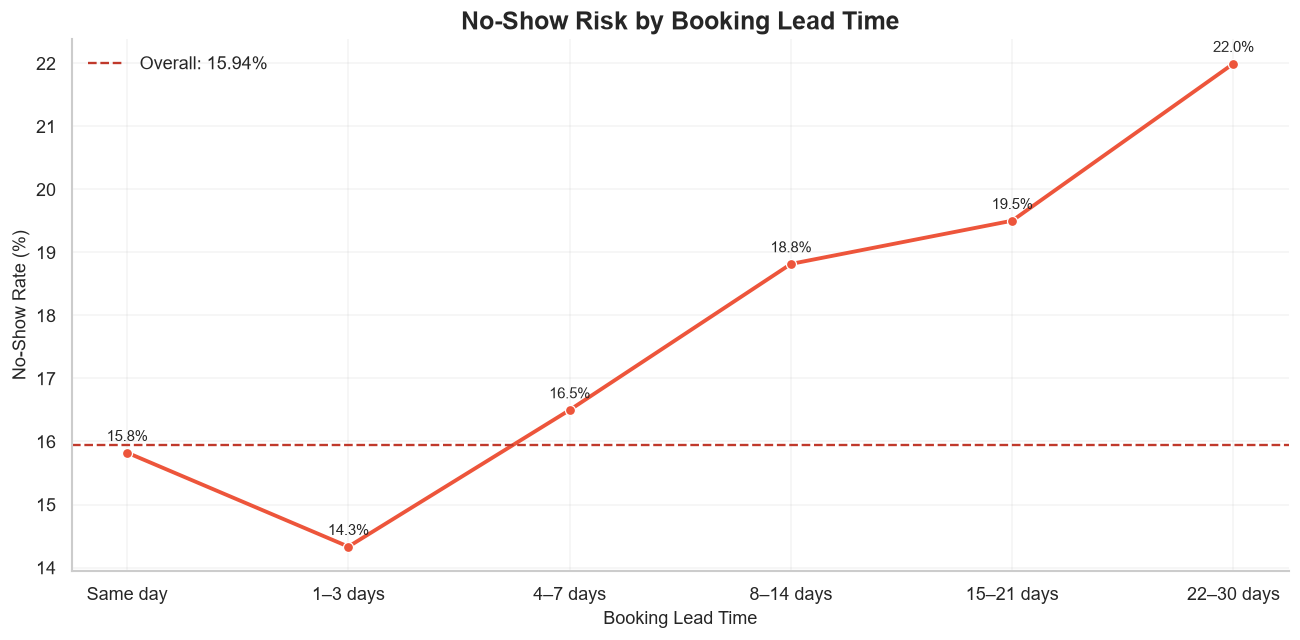

,lead_time_band,eligible_appointments,no_shows,no_show_rate_pct
0,Same day,20180,3193,15.82
1,1–3 days,25475,3651,14.33
2,4–7 days,15897,2623,16.50
3,8–14 days,8758,1648,18.82
4,15–21 days,1851,361,19.50
5,22–30 days,491,108,22.00


In [15]:
# Bucket lead time for a more business-friendly view than 31 individual points.
lead_bins = [-1, 0, 3, 7, 14, 21, 30]
lead_labels = ["Same day", "1–3 days", "4–7 days", "8–14 days", "15–21 days", "22–30 days"]

eligible["lead_time_band"] = pd.cut(
    eligible["booking_lead_days"],
    bins=lead_bins,
    labels=lead_labels,
)

lead_no_show = no_show_rate_table(eligible, "lead_time_band")
lead_no_show["lead_time_band"] = pd.Categorical(
    lead_no_show["lead_time_band"], categories=lead_labels, ordered=True
)
lead_no_show = lead_no_show.sort_values("lead_time_band")

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(
    data=lead_no_show,
    x="lead_time_band",
    y="no_show_rate_pct",
    marker="o",
    linewidth=2.3,
    color=ORANGE,
    ax=ax,
)
ax.axhline(overall_no_show_rate, linestyle="--", color=RED, linewidth=1.4,
           label=f"Overall: {overall_no_show_rate:.2f}%")
for x, y in zip(lead_no_show["lead_time_band"], lead_no_show["no_show_rate_pct"]):
    ax.annotate(f"{y:.1f}%", (x, y), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=9)
ax.set(title="No-Show Risk by Booking Lead Time", xlabel="Booking Lead Time", ylabel="No-Show Rate (%)")
ax.legend()
ax.grid(alpha=0.20)
plt.tight_layout()
plt.show()

display(lead_no_show)

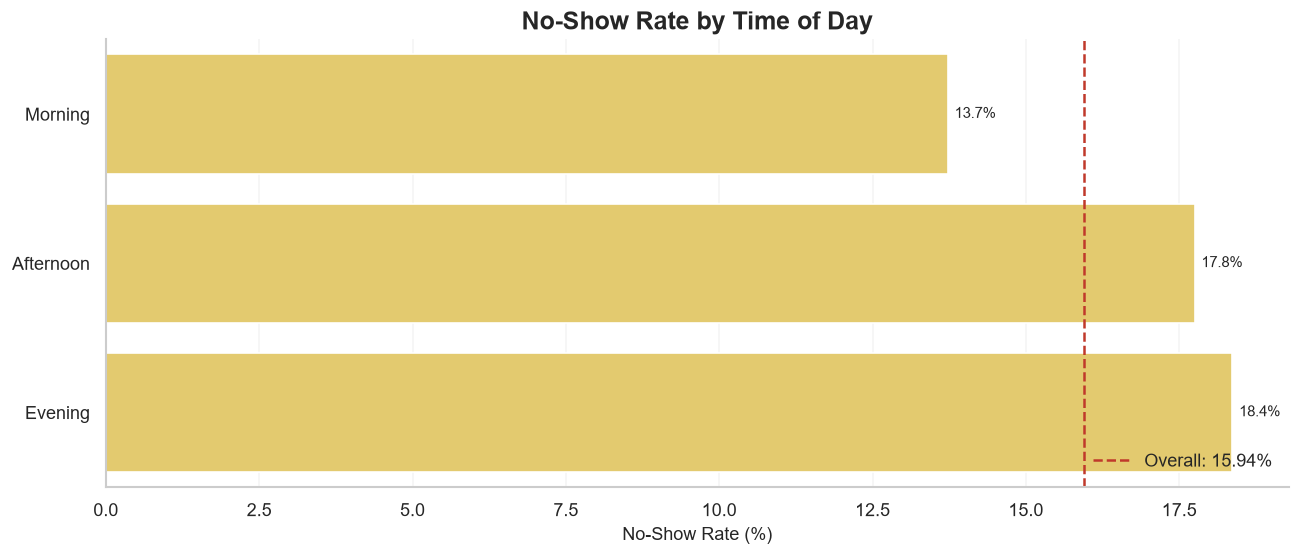

,time_of_day,eligible_appointments,no_shows,no_show_rate_pct
2,Morning,34868,4787,13.73
0,Afternoon,23231,4124,17.75
1,Evening,14553,2673,18.37


In [16]:
time_order = ["Morning", "Afternoon", "Evening"]
time_no_show = no_show_rate_table(eligible, "time_of_day")
time_no_show["time_of_day"] = pd.Categorical(
    time_no_show["time_of_day"], categories=time_order, ordered=True
)
time_no_show = time_no_show.sort_values("time_of_day")

plot_rate_bar(
    time_no_show,
    "time_of_day",
    "No-Show Rate by Time of Day",
    overall_rate=overall_no_show_rate,
    color=GOLD,
)
display(time_no_show)

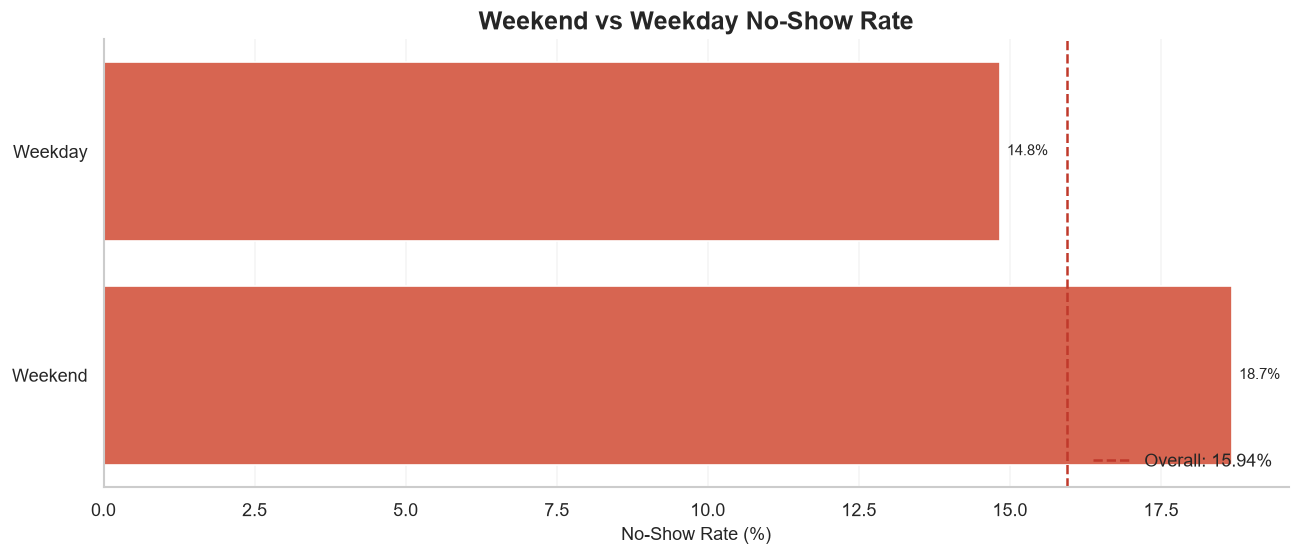

,day_type,eligible_appointments,no_shows,no_show_rate_pct
1,Weekend,20921,3908,18.68
0,Weekday,51731,7676,14.84


In [17]:
eligible["day_type"] = np.where(
    eligible["appointment_day_of_week"].isin([5, 6]),
    "Weekend",
    "Weekday",
)
day_type_no_show = no_show_rate_table(eligible, "day_type")

plot_rate_bar(
    day_type_no_show,
    "day_type",
    "Weekend vs Weekday No-Show Rate",
    overall_rate=overall_no_show_rate,
    color=ORANGE,
)
display(day_type_no_show)

,appointment_type,eligible_appointments,no_shows,no_show_rate_pct
0,Home Visit,9742,2557,26.25
2,Video Consult,15349,3232,21.06
1,In-Clinic,47561,5795,12.18


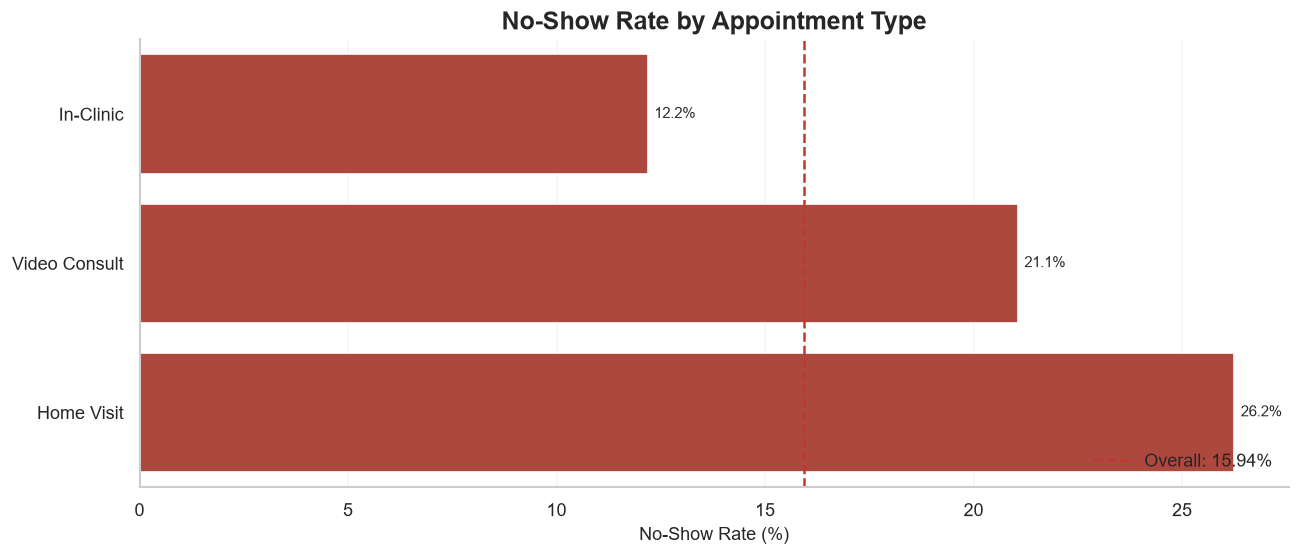

In [18]:
appointment_type_no_show = no_show_rate_table(eligible, "appointment_type")
booking_channel_no_show = no_show_rate_table(eligible, "booking_channel")

display(appointment_type_no_show)
plot_rate_bar(
    appointment_type_no_show,
    "appointment_type",
    "No-Show Rate by Appointment Type",
    overall_rate=overall_no_show_rate,
    color=RED,
)

,booking_channel,eligible_appointments,no_shows,no_show_rate_pct
3,Walk-In,7281,1520,20.88
2,Partner App,3594,651,18.11
4,Website,17964,3090,17.20
1,Call Centre,10855,1650,15.20
0,Apollo App,32958,4673,14.18


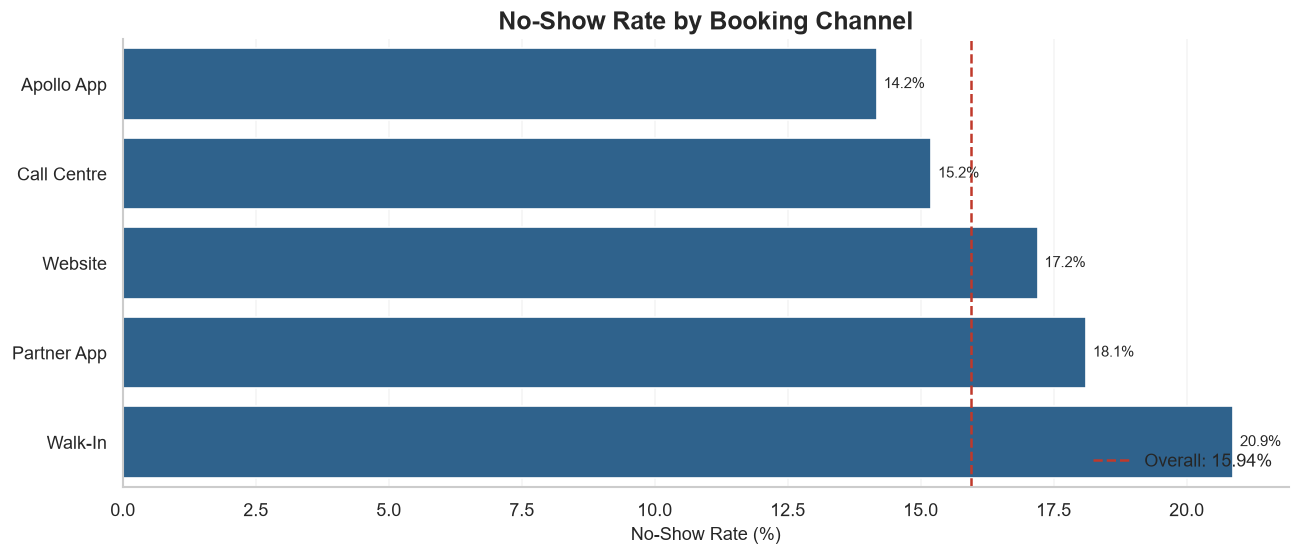

In [19]:
display(booking_channel_no_show)
plot_rate_bar(
    booking_channel_no_show,
    "booking_channel",
    "No-Show Rate by Booking Channel",
    overall_rate=overall_no_show_rate,
    color=BLUE,
)

## 4. Reminder & Patient Engagement Effectiveness
This section measures not only observed rates, but also the change versus the **No Reminder** baseline.

,reminder_type,eligible_appointments,no_shows,no_show_rate_pct,pp_reduction_vs_no_reminder,relative_reduction_pct
0,No Reminder,10977,3311,30.16,0.00,0.00
3,SMS Only,14527,2363,16.27,13.90,46.07
1,SMS + WhatsApp,25273,3414,13.51,16.65,55.22
2,SMS + WhatsApp + Call,21875,2496,11.41,18.75,62.17


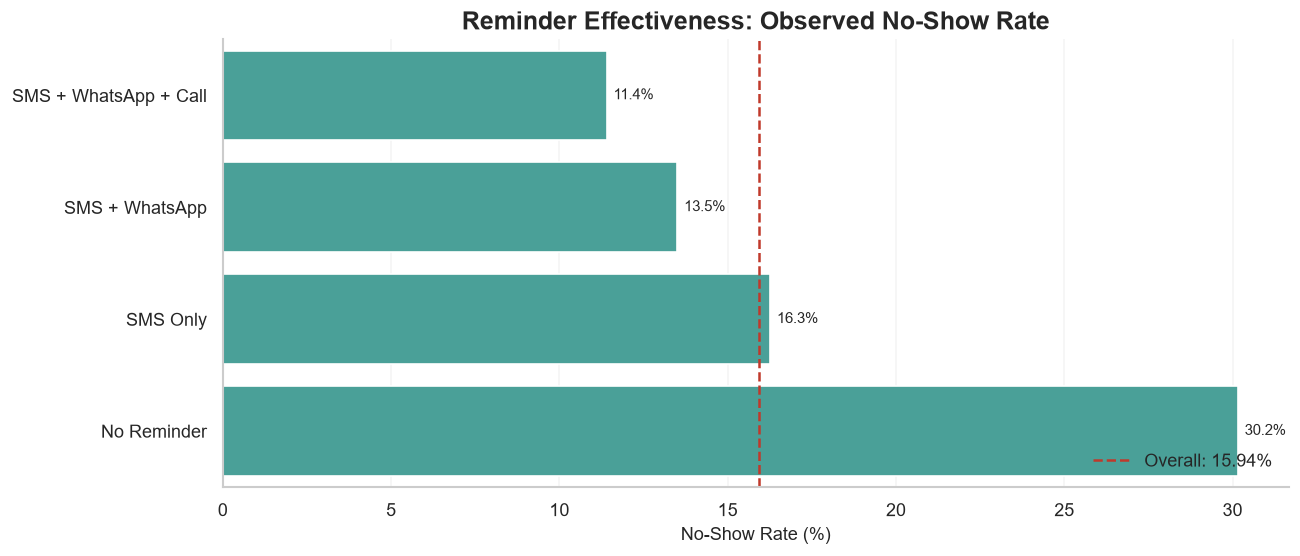

In [20]:
reminder_analysis = no_show_rate_table(eligible, "reminder_type")
baseline_rate = float(
    reminder_analysis.loc[
        reminder_analysis["reminder_type"].eq("No Reminder"),
        "no_show_rate_pct"
    ].iloc[0]
)

reminder_analysis["pp_reduction_vs_no_reminder"] = (
    baseline_rate - reminder_analysis["no_show_rate_pct"]
)
reminder_analysis["relative_reduction_pct"] = (
    reminder_analysis["pp_reduction_vs_no_reminder"] / baseline_rate * 100
)

display(reminder_analysis.round(2))
plot_rate_bar(
    reminder_analysis,
    "reminder_type",
    "Reminder Effectiveness: Observed No-Show Rate",
    overall_rate=overall_no_show_rate,
    color=TEAL,
)

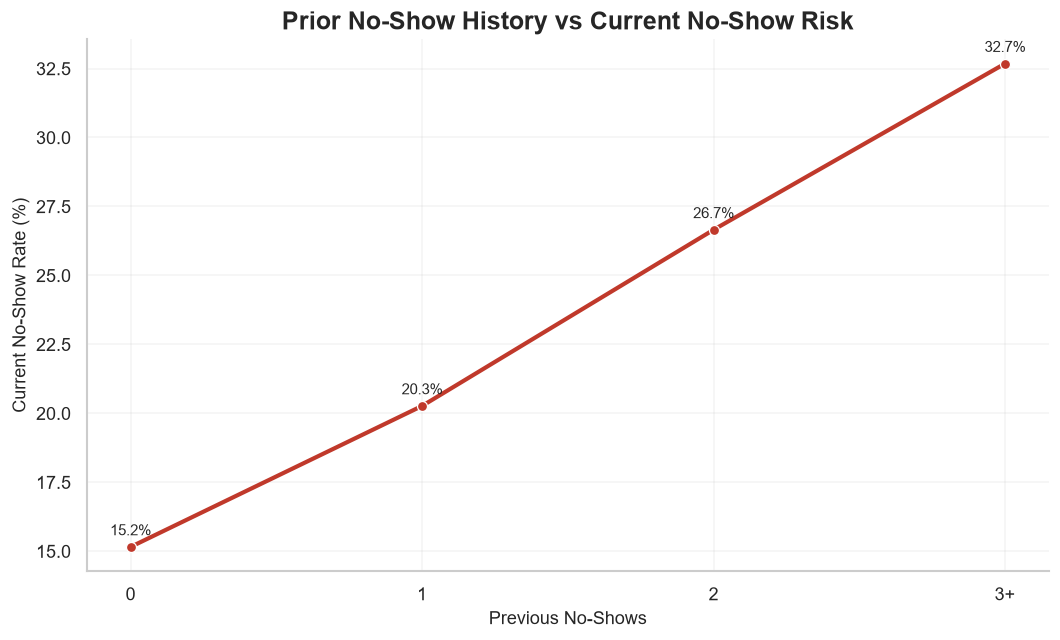

,prior_no_show_band,eligible_appointments,no_shows,no_show_rate_pct
0,0,63014,9549,15.15
1,1,8502,1723,20.27
2,2,983,262,26.65
3,3+,153,50,32.68


In [21]:
# Collapse sparse high-history values into a stable business segment.
eligible["prior_no_show_band"] = pd.cut(
    eligible["patient_prior_no_shows"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"],
)

prior_history = no_show_rate_table(eligible, "prior_no_show_band")
prior_history["prior_no_show_band"] = pd.Categorical(
    prior_history["prior_no_show_band"],
    categories=["0", "1", "2", "3+"],
    ordered=True,
)
prior_history = prior_history.sort_values("prior_no_show_band")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.lineplot(
    data=prior_history,
    x="prior_no_show_band",
    y="no_show_rate_pct",
    marker="o",
    linewidth=2.5,
    color=RED,
    ax=ax,
)
for x, y in zip(prior_history["prior_no_show_band"], prior_history["no_show_rate_pct"]):
    ax.annotate(f"{y:.1f}%", (x, y), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=9)
ax.set(
    title="Prior No-Show History vs Current No-Show Risk",
    xlabel="Previous No-Shows",
    ylabel="Current No-Show Rate (%)",
)
ax.grid(alpha=0.20)
plt.tight_layout()
plt.show()

display(prior_history)

,apollo_member,eligible_appointments,no_shows,no_show_rate_pct
0,No,56428,9530,16.89
1,Yes,16224,2054,12.66


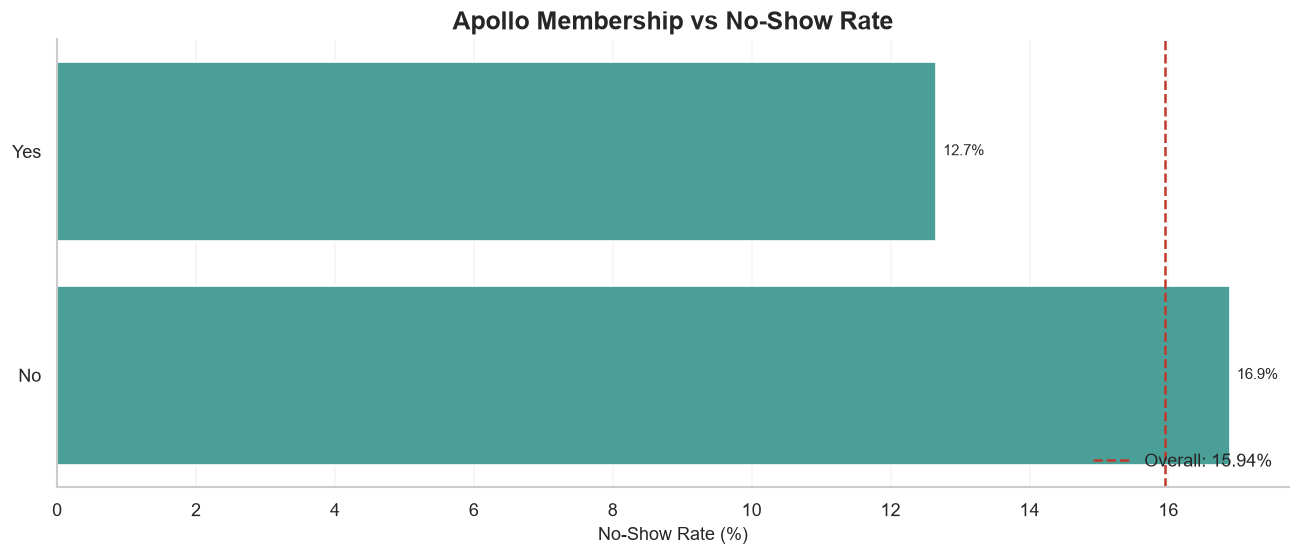

In [22]:
membership_analysis = no_show_rate_table(eligible, "apollo_member")
repeat_visit_analysis = no_show_rate_table(eligible, "repeat_visit")

display(membership_analysis)
plot_rate_bar(
    membership_analysis,
    "apollo_member",
    "Apollo Membership vs No-Show Rate",
    overall_rate=overall_no_show_rate,
    color=TEAL,
)

,repeat_visit,eligible_appointments,no_shows,no_show_rate_pct
0,No,9182,6132,66.78
1,Yes,63470,5452,8.59


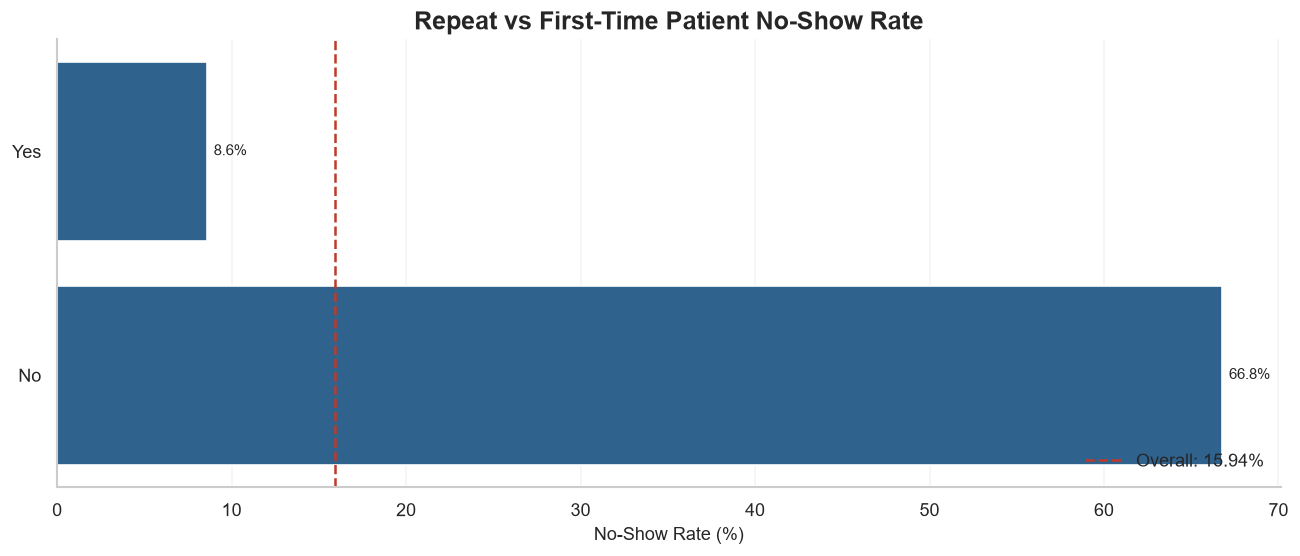

In [23]:
display(repeat_visit_analysis)
plot_rate_bar(
    repeat_visit_analysis,
    "repeat_visit",
    "Repeat vs First-Time Patient No-Show Rate",
    overall_rate=overall_no_show_rate,
    color=BLUE,
)

## 5. Patient & Demographic Segmentation

,age_group,eligible_appointments,no_shows,no_show_rate_pct
1,Child (0-12),11745,1590,13.54
4,Teen (13-18),6379,939,14.72
5,Young Adult (19-30),10017,1797,17.94
0,Adult (31-45),15133,2731,18.05
2,Middle-aged (46-60),14862,2491,16.76
3,Senior (60+),14516,2036,14.03


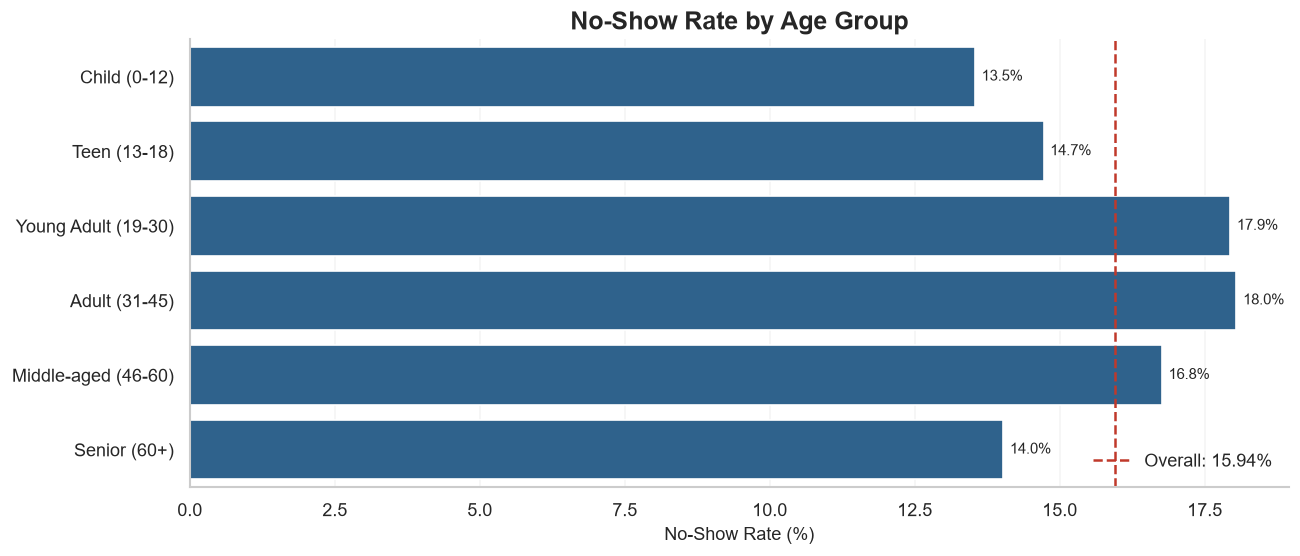

In [24]:
age_order = [
    "Child (0-12)",
    "Teen (13-18)",
    "Young Adult (19-30)",
    "Adult (31-45)",
    "Middle-aged (46-60)",
    "Senior (60+)",
]
age_group_analysis = no_show_rate_table(eligible, "age_group")
age_group_analysis["age_group"] = pd.Categorical(
    age_group_analysis["age_group"], categories=age_order, ordered=True
)
age_group_analysis = age_group_analysis.sort_values("age_group")

display(age_group_analysis)
plot_rate_bar(
    age_group_analysis,
    "age_group",
    "No-Show Rate by Age Group",
    overall_rate=overall_no_show_rate,
    color=BLUE,
)

,patient_gender,eligible_appointments,no_shows,no_show_rate_pct
0,Female,37589,6029,16.04
1,Male,35063,5555,15.84


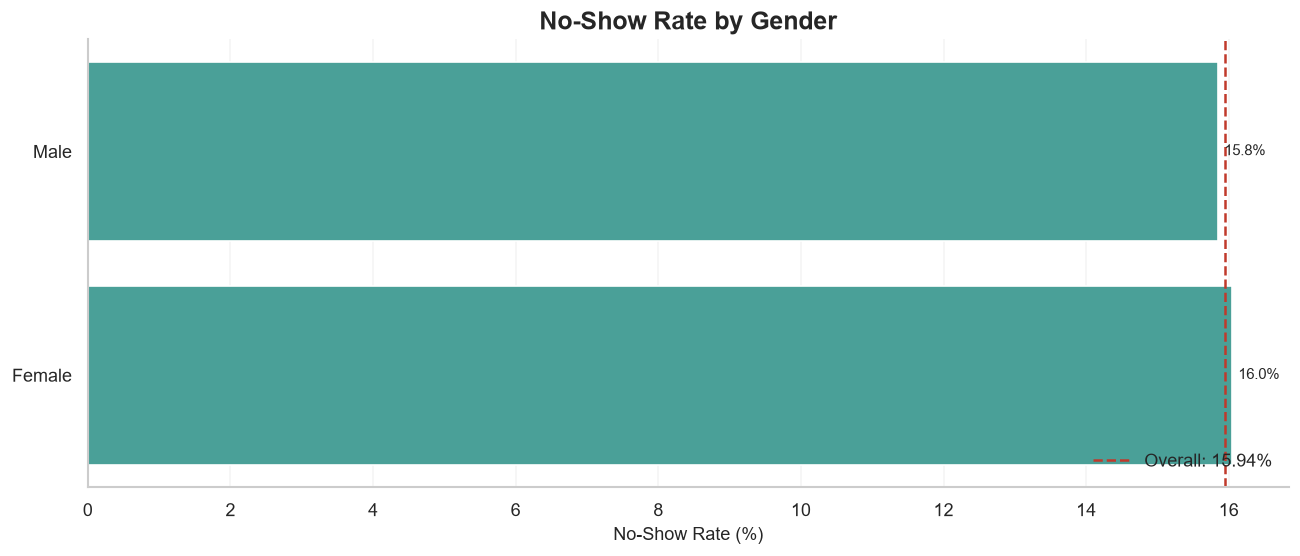

In [25]:
gender_analysis = no_show_rate_table(eligible, "patient_gender")
display(gender_analysis)
plot_rate_bar(
    gender_analysis,
    "patient_gender",
    "No-Show Rate by Gender",
    overall_rate=overall_no_show_rate,
    color=TEAL,
)

,patient_chronic_condition,eligible_appointments,no_shows,no_show_rate_pct
0,Asthma,9098,1520,16.71
2,Heart Disease,9155,1494,16.32
5,No chronic condition,27144,4314,15.89
1,Diabetes,9010,1421,15.77
3,Hypertension,9100,1417,15.57
4,Hypothyroidism,9145,1418,15.51


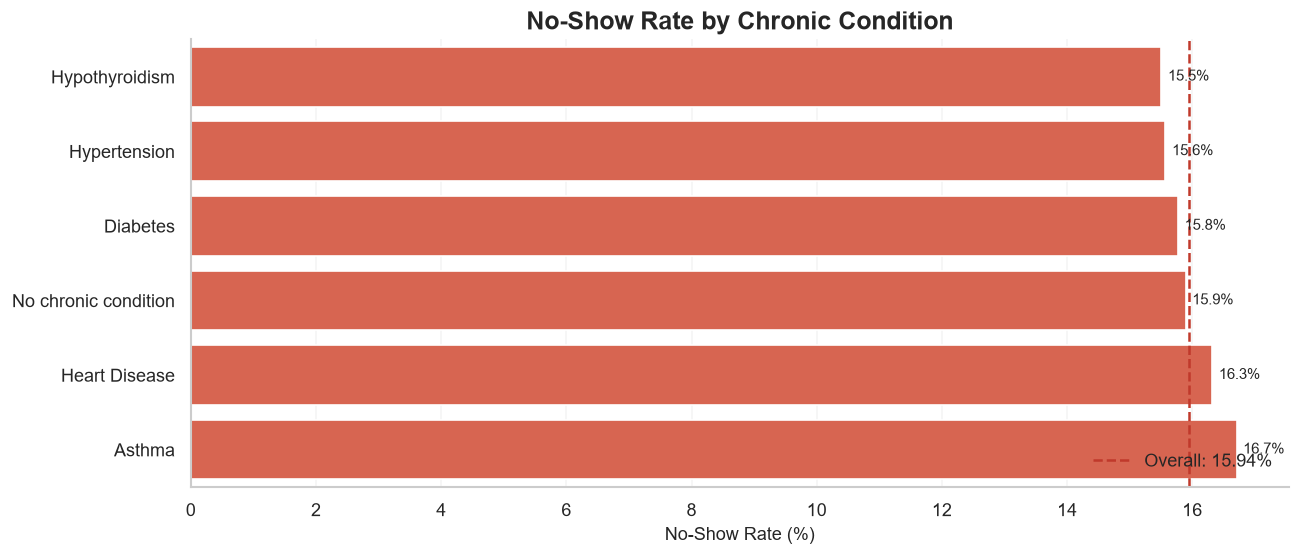

In [26]:
chronic_analysis = no_show_rate_table(eligible, "patient_chronic_condition")
chronic_analysis["patient_chronic_condition"] = chronic_analysis["patient_chronic_condition"].replace(
    {"None": "No chronic condition"}
)

display(chronic_analysis)
plot_rate_bar(
    chronic_analysis,
    "patient_chronic_condition",
    "No-Show Rate by Chronic Condition",
    overall_rate=overall_no_show_rate,
    color=ORANGE,
)

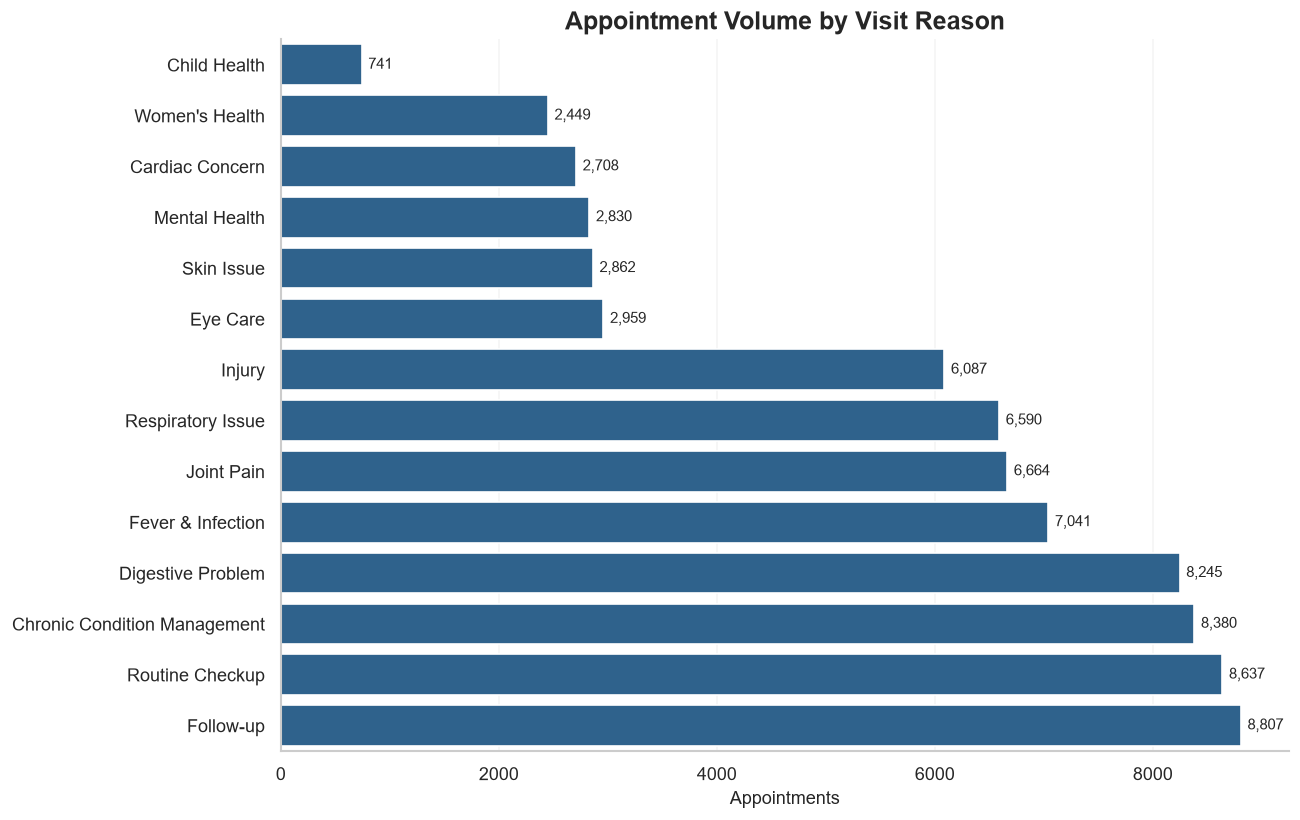

,visit_reason,appointments
0,Follow-up,8807
1,Routine Checkup,8637
2,Chronic Condition Management,8380
3,Digestive Problem,8245
4,Fever & Infection,7041
5,Joint Pain,6664
6,Respiratory Issue,6590
7,Injury,6087
8,Eye Care,2959
9,Skin Issue,2862


In [27]:
visit_reason_volume = (
    df["visit_reason"]
    .value_counts()
    .rename_axis("visit_reason")
    .reset_index(name="appointments")
    .sort_values("appointments", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=visit_reason_volume, x="appointments", y="visit_reason", color=BLUE, ax=ax)
ax.set(title="Appointment Volume by Visit Reason", xlabel="Appointments", ylabel="")
add_bar_labels(ax, suffix="", decimals=0)
ax.grid(axis="x", alpha=0.20)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

display(visit_reason_volume.sort_values("appointments", ascending=False))

,visit_reason,eligible_appointments,no_shows,no_show_rate_pct
12,Skin Issue,2782,467,16.79
8,Joint Pain,6469,1082,16.73
0,Cardiac Concern,2639,430,16.29
9,Mental Health,2733,445,16.28
3,Digestive Problem,7984,1297,16.24
7,Injury,5884,949,16.13
5,Fever & Infection,6808,1095,16.08
10,Respiratory Issue,6383,1020,15.98
13,Women's Health,2362,377,15.96
11,Routine Checkup,8377,1309,15.63


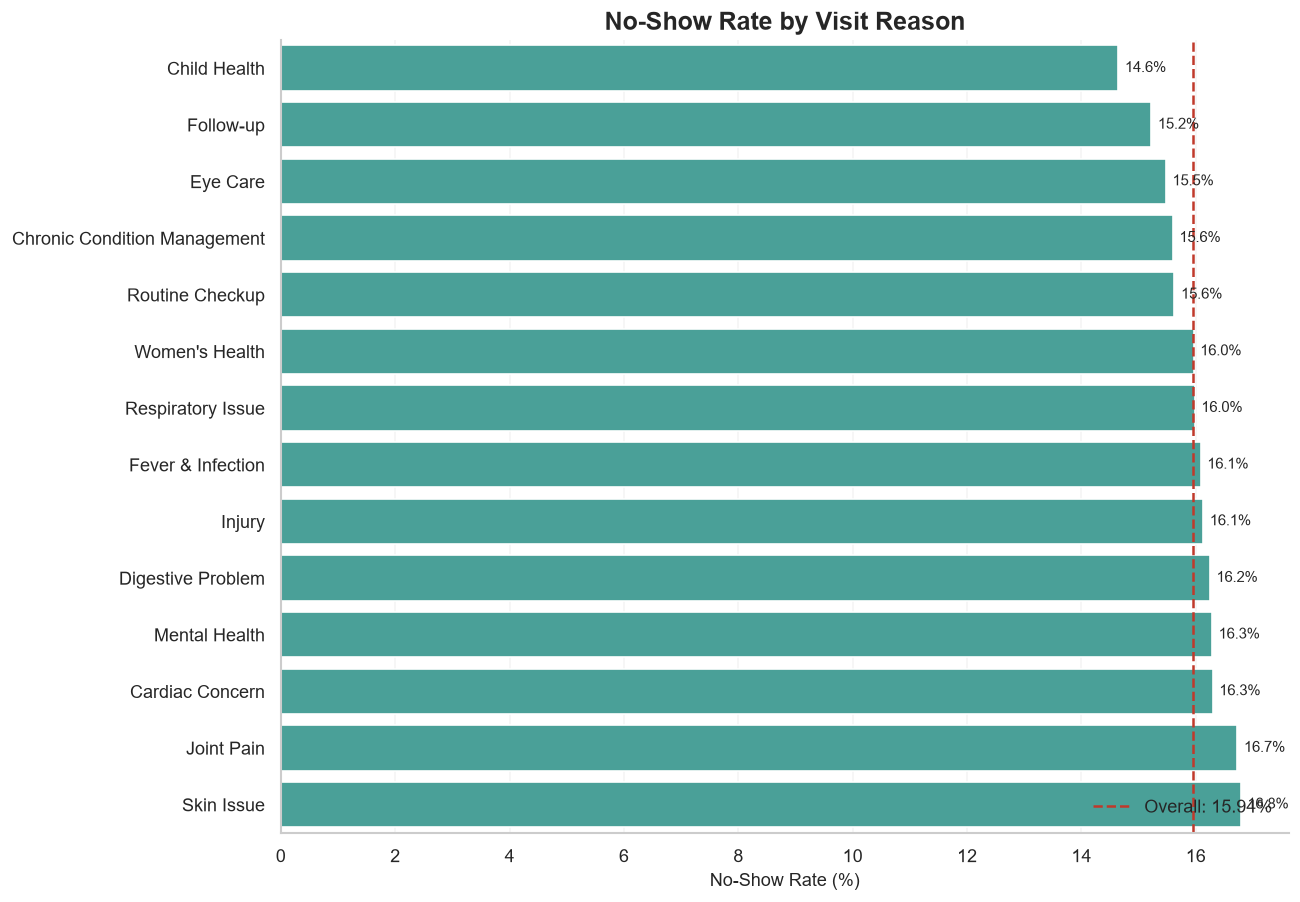

In [28]:
visit_reason_no_show = no_show_rate_table(eligible, "visit_reason")
display(visit_reason_no_show)
plot_rate_bar(
    visit_reason_no_show,
    "visit_reason",
    "No-Show Rate by Visit Reason",
    overall_rate=overall_no_show_rate,
    color=TEAL,
)

,count,mean,median,min,max
specialty,,,,,
Gynaecology,"4,113.00",41.69,42.00,1.00,85.00
Paediatrics,"6,382.00",9.25,9.00,1.00,18.00
Psychiatry,"2,989.00",41.96,42.00,1.00,85.00


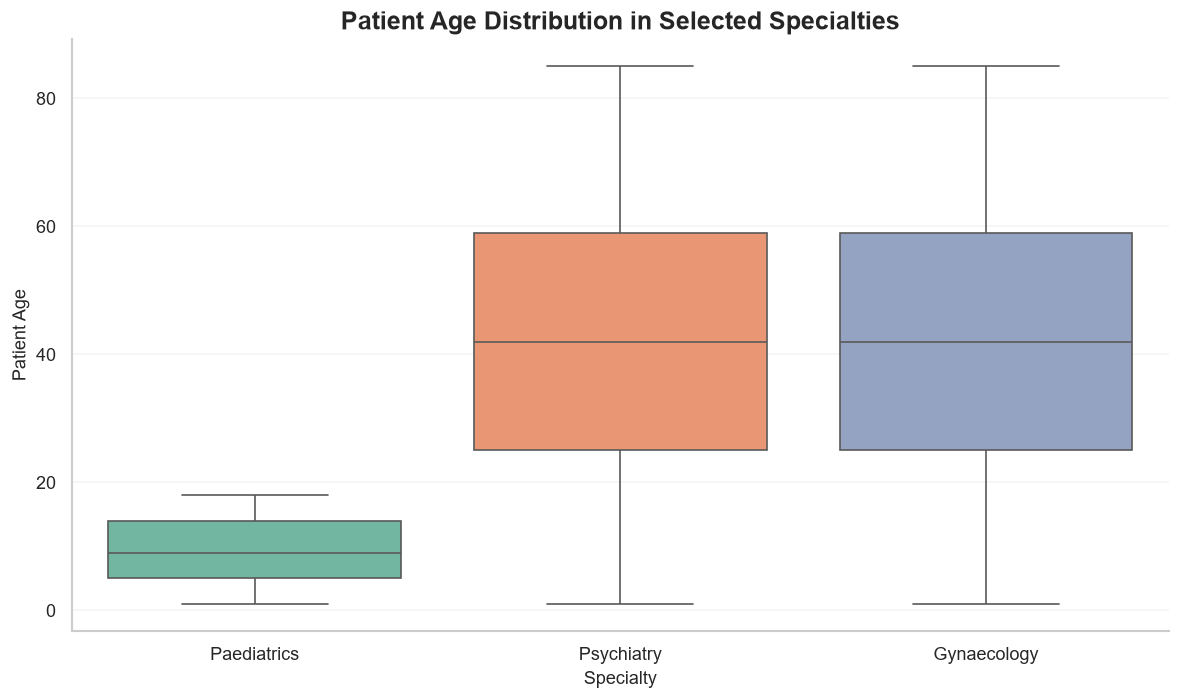

In [29]:
selected_specialties = ["Paediatrics", "Gynaecology", "Psychiatry"]
age_distribution = df.loc[
    df["specialty"].isin(selected_specialties),
    ["specialty", "patient_age"]
].copy()

display(
    age_distribution.groupby("specialty")["patient_age"]
    .describe()[["count", "mean", "50%", "min", "max"]]
    .rename(columns={"50%": "median"})
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=age_distribution,
    x="specialty",
    y="patient_age",
    hue="specialty",
    palette="Set2",
    legend=False,
    ax=ax,
)
ax.set(
    title="Patient Age Distribution in Selected Specialties",
    xlabel="Specialty",
    ylabel="Patient Age",
)
ax.grid(axis="y", alpha=0.20)
plt.tight_layout()
plt.show()

## 6. Financial Performance
Revenue analysis is scoped to `Completed` appointments. No-show financial impact is shown as **estimated gross consultation-fee exposure**, not realized accounting loss.

In [30]:
no_show_fee_exposure = (
    df.loc[df["appointment_status"].eq("No-Show"), "consultation_fee"].sum()
)

print("Estimated gross consultation-fee exposure from No-Shows:")
print(format_inr(no_show_fee_exposure))
print(f"Exact amount: ₹{no_show_fee_exposure:,.0f}")

Estimated gross consultation-fee exposure from No-Shows:
₹1.97 Cr
Exact amount: ₹19,725,460


,specialty,completed_appointments,average_revenue
11,Psychiatry,1958,"2,640.45"
7,Neurology,3899,"2,076.48"
13,Urology,1729,"1,988.62"
0,Cardiology,3507,"1,940.77"
4,Gastroenterology,1972,"1,896.82"
3,Endocrinology,1504,"1,812.68"
12,Pulmonology,1961,"1,803.23"
9,Orthopaedics,4189,"1,547.20"
6,Gynaecology,3134,"1,499.59"
8,Ophthalmology,2349,"1,467.13"


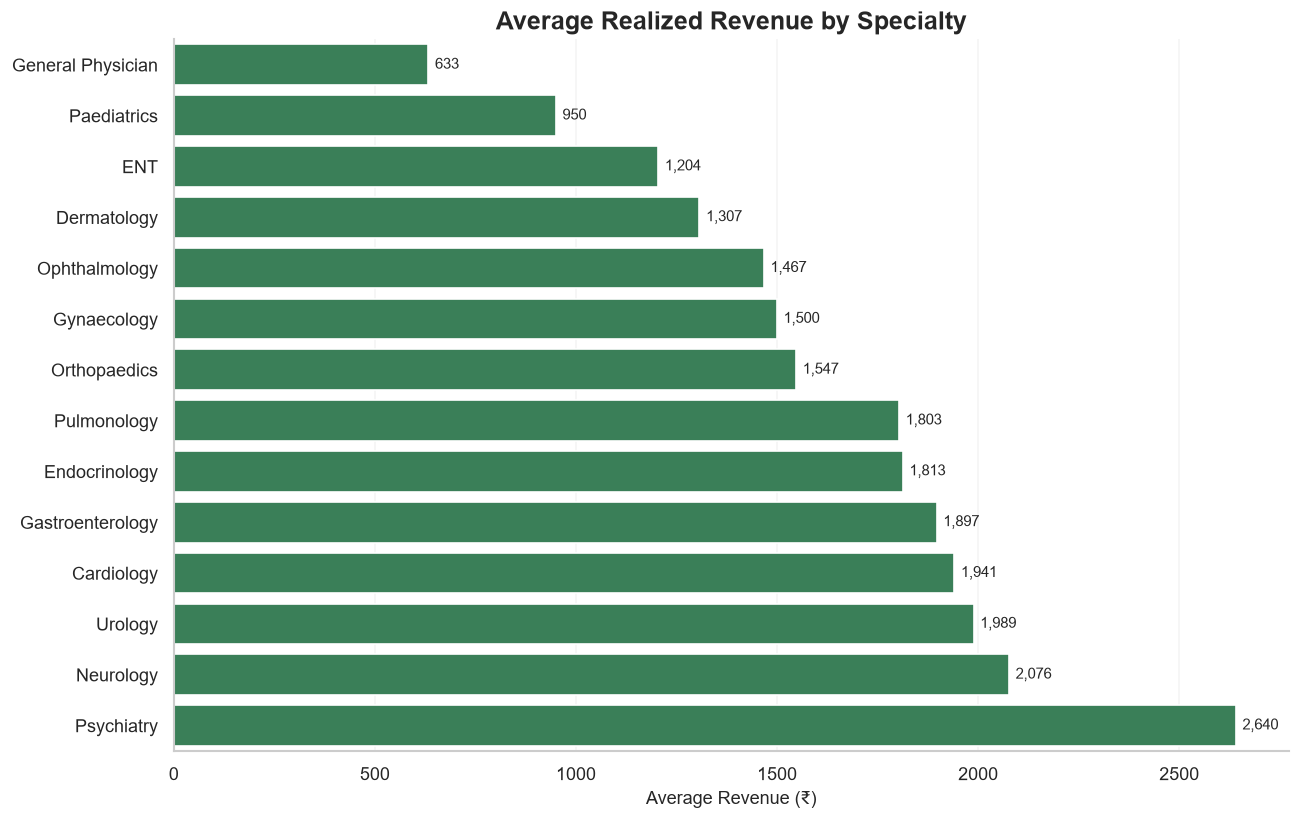

In [31]:
avg_revenue_specialty = (
    completed.groupby("specialty")
    .agg(
        completed_appointments=("appointment_id", "size"),
        average_revenue=("revenue_realized", "mean"),
    )
    .reset_index()
    .sort_values("average_revenue", ascending=False)
)

display(avg_revenue_specialty)

plot_data = avg_revenue_specialty.sort_values("average_revenue", ascending=True)
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=plot_data, x="average_revenue", y="specialty", color=GREEN, ax=ax)
ax.set(title="Average Realized Revenue by Specialty", xlabel="Average Revenue (₹)", ylabel="")
add_bar_labels(ax, suffix="", decimals=0)
ax.grid(axis="x", alpha=0.20)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

,appointment_type,completed_appointments,average_revenue
0,Home Visit,6436,"1,960.05"
1,In-Clinic,37938,"1,299.83"
2,Video Consult,10901,"1,097.70"


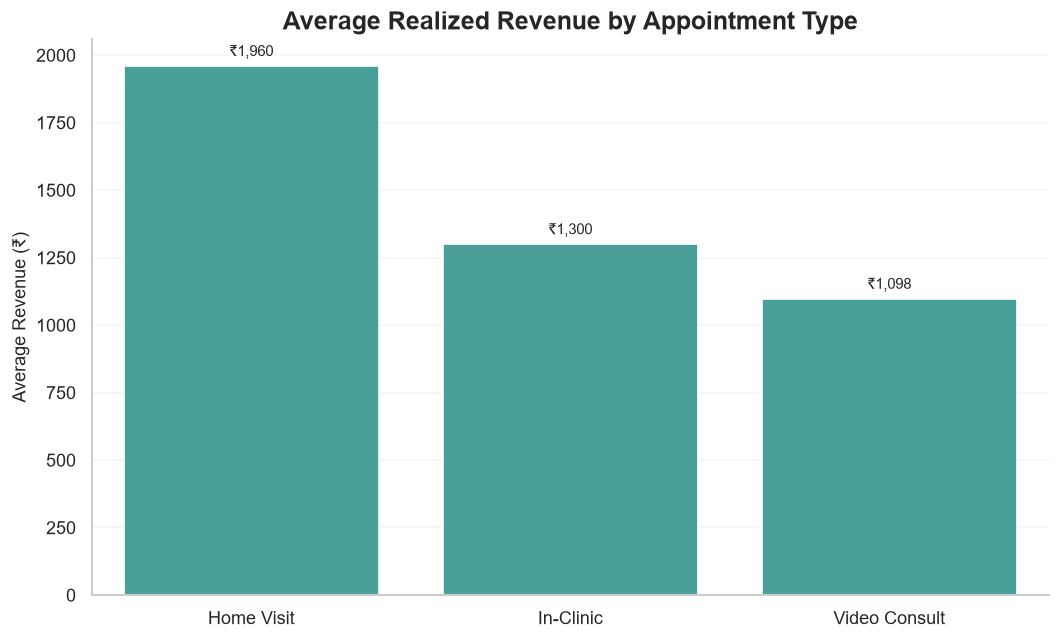

In [32]:
avg_revenue_type = (
    completed.groupby("appointment_type")
    .agg(
        completed_appointments=("appointment_id", "size"),
        average_revenue=("revenue_realized", "mean"),
    )
    .reset_index()
    .sort_values("average_revenue", ascending=False)
)

display(avg_revenue_type)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(data=avg_revenue_type, x="appointment_type", y="average_revenue", color=TEAL, ax=ax)
ax.set(title="Average Realized Revenue by Appointment Type", xlabel="", ylabel="Average Revenue (₹)")
for container in ax.containers:
    ax.bar_label(container, labels=[f"₹{v:,.0f}" for v in avg_revenue_type["average_revenue"]],
                 padding=4, fontsize=9)
ax.grid(axis="y", alpha=0.20)
plt.tight_layout()
plt.show()

,city,completed_appointments,total_revenue
1,Bengaluru,6405,9990616
6,Delhi,7834,9958247
13,Mumbai,7318,8989613
7,Hyderabad,5496,7503245
4,Chennai,5132,7188473
11,Kolkata,4280,6543084
14,Pune,3179,4734139
0,Ahmedabad,2607,3956890
12,Lucknow,2254,3177444
8,Indore,1679,2223207


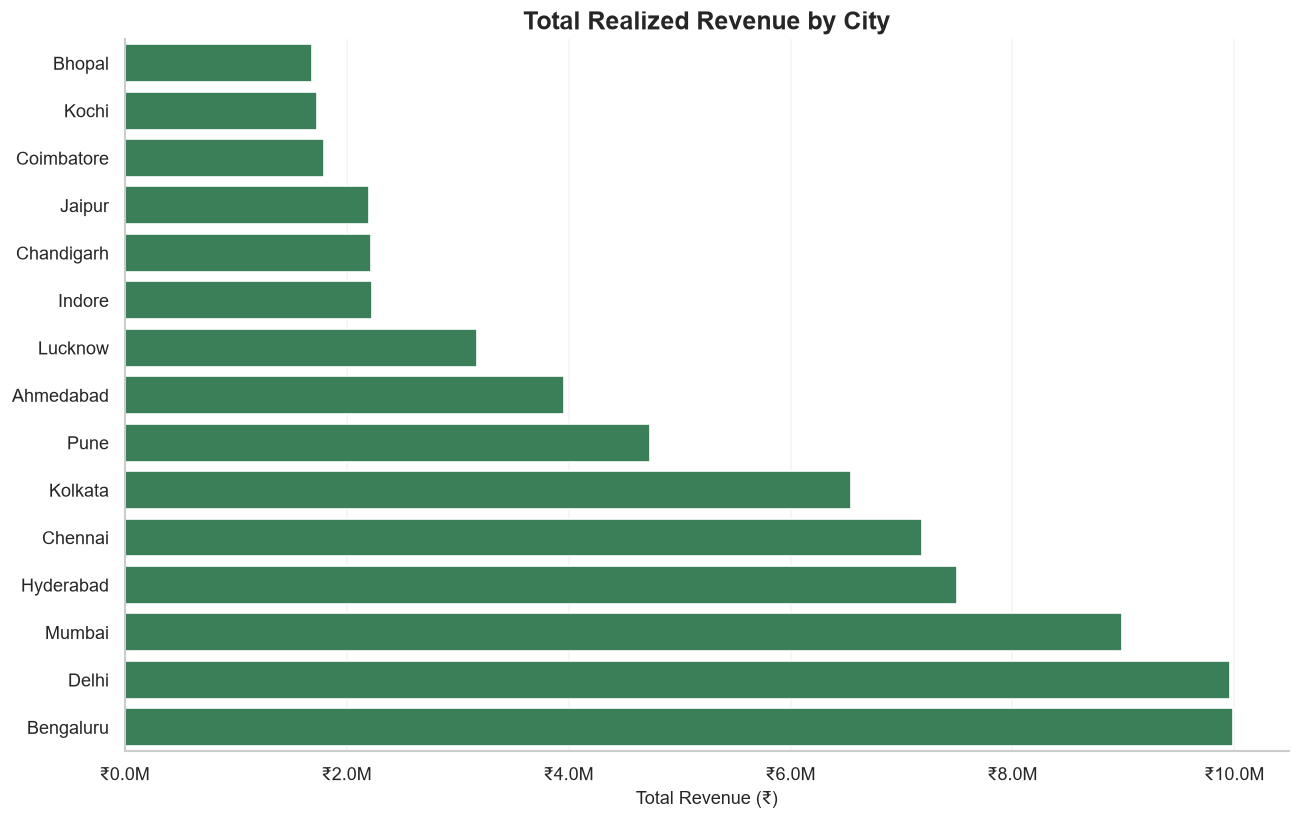

In [33]:
city_revenue = (
    completed.groupby("city")
    .agg(
        completed_appointments=("appointment_id", "size"),
        total_revenue=("revenue_realized", "sum"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

display(city_revenue)

plot_data = city_revenue.sort_values("total_revenue", ascending=True)
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=plot_data, x="total_revenue", y="city", color=GREEN, ax=ax)
ax.set(title="Total Realized Revenue by City", xlabel="Total Revenue (₹)", ylabel="")
ax.xaxis.set_major_formatter(lambda x, pos: f"₹{x/1e6:.1f}M")
ax.grid(axis="x", alpha=0.20)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

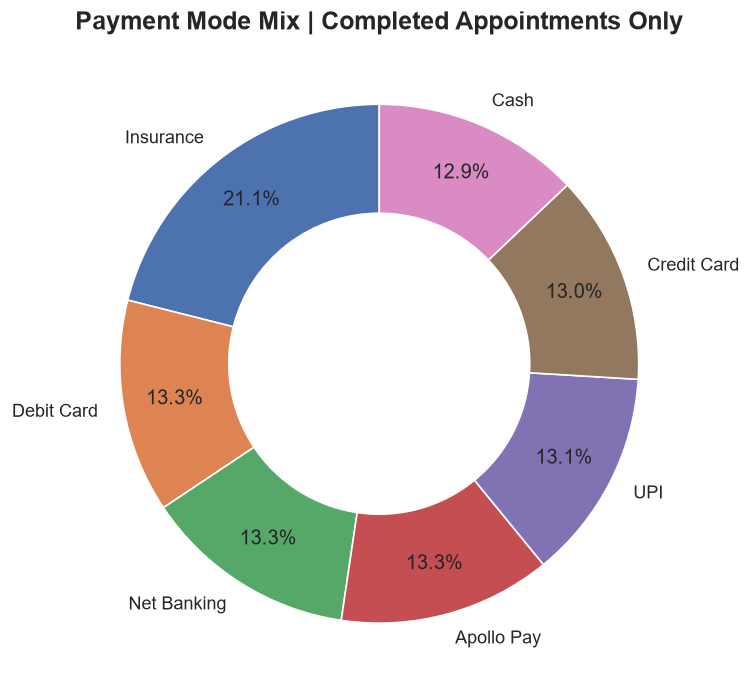

,payment_mode,transactions,share_pct
0,Insurance,11641,21.06
1,Debit Card,7353,13.30
2,Net Banking,7349,13.30
3,Apollo Pay,7324,13.25
4,UPI,7259,13.13
5,Credit Card,7213,13.05
6,Cash,7136,12.91


In [34]:
# Payment mode mix must use Completed appointments only.
payment_mix = (
    completed["payment_mode"]
    .value_counts()
    .rename_axis("payment_mode")
    .reset_index(name="transactions")
)
payment_mix["share_pct"] = payment_mix["transactions"] / payment_mix["transactions"].sum() * 100

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    payment_mix["transactions"],
    labels=payment_mix["payment_mode"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
    pctdistance=0.80,
)
ax.set_title("Payment Mode Mix | Completed Appointments Only")
plt.tight_layout()
plt.show()

display(payment_mix)

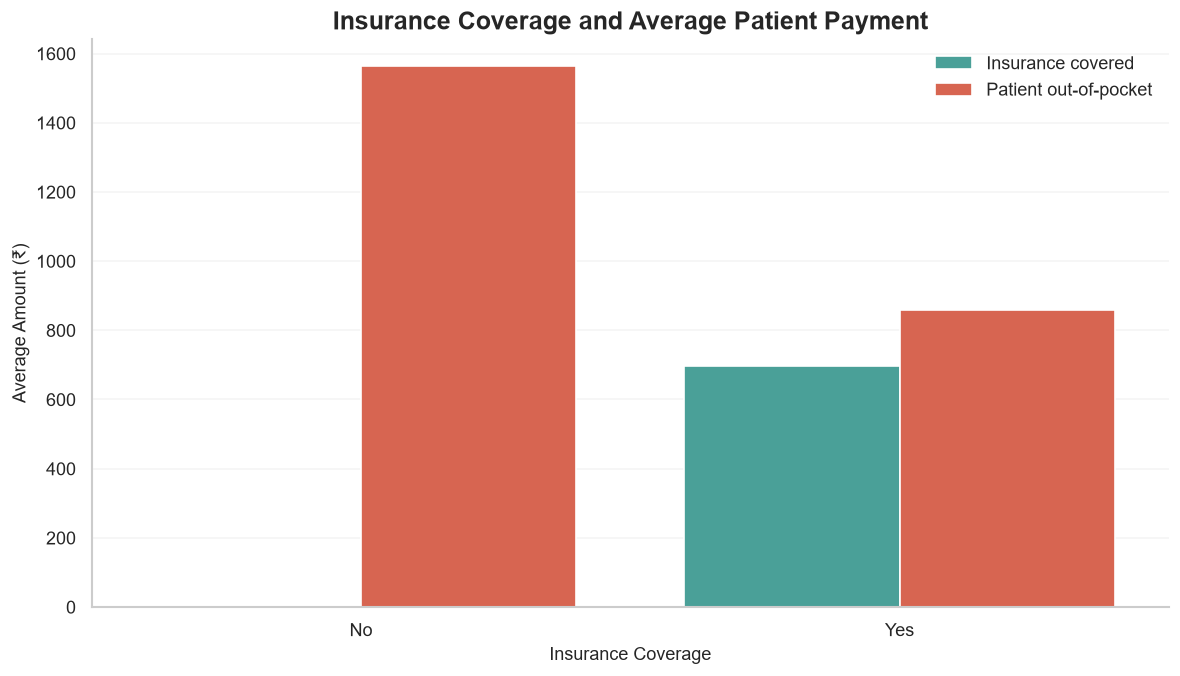

,insurance_coverage,completed_appointments,avg_insurance_covered,avg_out_of_pocket
0,No,37523,0.00,"1,562.82"
1,Yes,17752,697.17,859.18


In [35]:
insurance_analysis = (
    completed.groupby("insurance_coverage")
    .agg(
        completed_appointments=("appointment_id", "size"),
        avg_insurance_covered=("insurance_covered_amount", "mean"),
        avg_out_of_pocket=("patient_out_of_pocket", "mean"),
    )
    .reset_index()
)

insurance_long = insurance_analysis.melt(
    id_vars="insurance_coverage",
    value_vars=["avg_insurance_covered", "avg_out_of_pocket"],
    var_name="payment_component",
    value_name="average_amount",
)
insurance_long["payment_component"] = insurance_long["payment_component"].map({
    "avg_insurance_covered": "Insurance covered",
    "avg_out_of_pocket": "Patient out-of-pocket",
})

fig, ax = plt.subplots(figsize=(10, 5.8))
sns.barplot(
    data=insurance_long,
    x="insurance_coverage",
    y="average_amount",
    hue="payment_component",
    palette=[TEAL, ORANGE],
    ax=ax,
)
ax.set(
    title="Insurance Coverage and Average Patient Payment",
    xlabel="Insurance Coverage",
    ylabel="Average Amount (₹)",
)
ax.legend(title="")
ax.grid(axis="y", alpha=0.20)
plt.tight_layout()
plt.show()

display(insurance_analysis)

## 7. Doctor Utilisation & Service Quality
Only `Completed` appointments are used for appointment-level quality metrics.

,specialty,completed_appointments,avg_doctor_utilization
4,Gastroenterology,1972,77.26
3,Endocrinology,1504,77.15
0,Cardiology,3507,76.81
6,Gynaecology,3134,76.80
10,Paediatrics,4900,76.66
7,Neurology,3899,76.63
5,General Physician,14981,76.59
13,Urology,1729,76.44
9,Orthopaedics,4189,76.43
1,Dermatology,5347,76.42


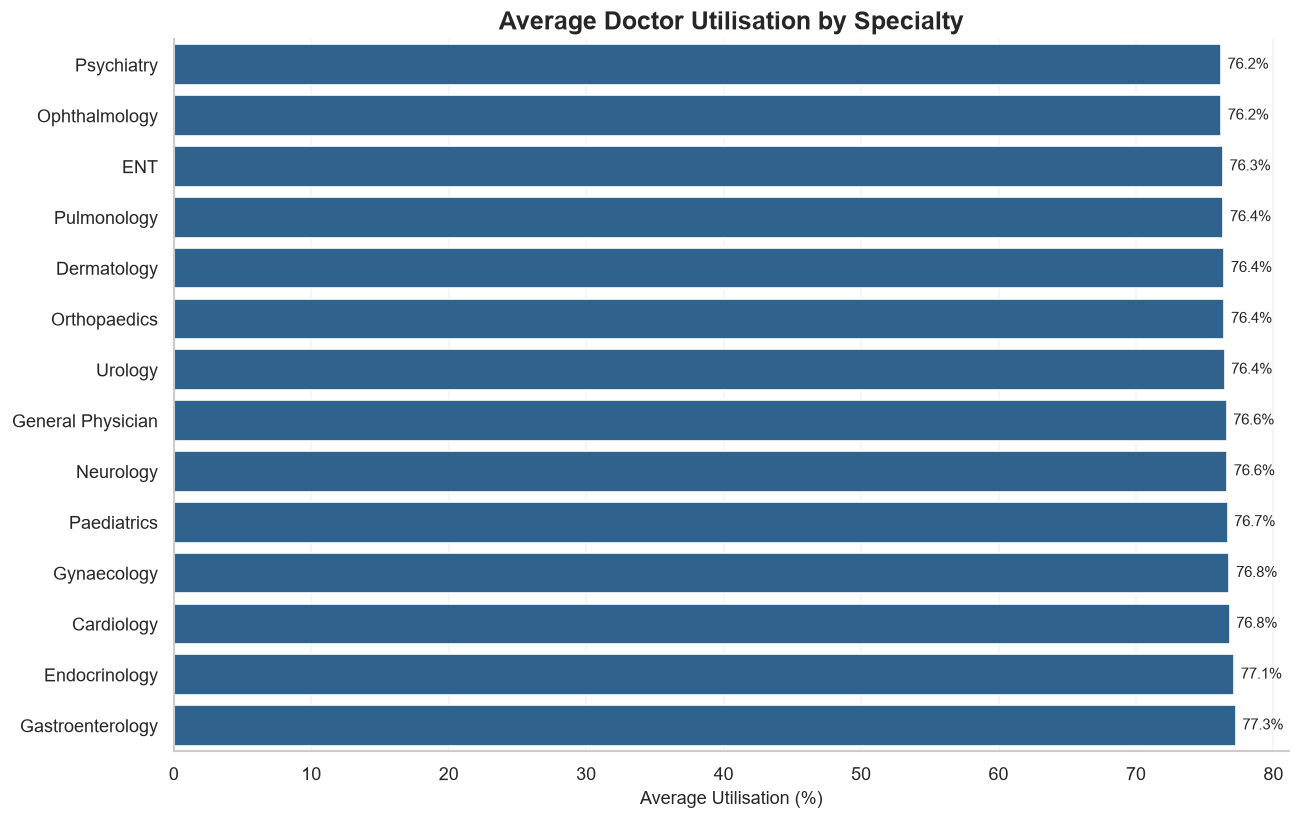

In [36]:
doctor_utilization = (
    completed.groupby("specialty")
    .agg(
        completed_appointments=("appointment_id", "size"),
        avg_doctor_utilization=("doctor_utilization_pct", "mean"),
    )
    .reset_index()
    .sort_values("avg_doctor_utilization", ascending=False)
)

display(doctor_utilization)

plot_data = doctor_utilization.sort_values("avg_doctor_utilization", ascending=True)
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=plot_data, x="avg_doctor_utilization", y="specialty", color=BLUE, ax=ax)
ax.set(title="Average Doctor Utilisation by Specialty", xlabel="Average Utilisation (%)", ylabel="")
add_bar_labels(ax, suffix="%")
ax.grid(axis="x", alpha=0.20)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

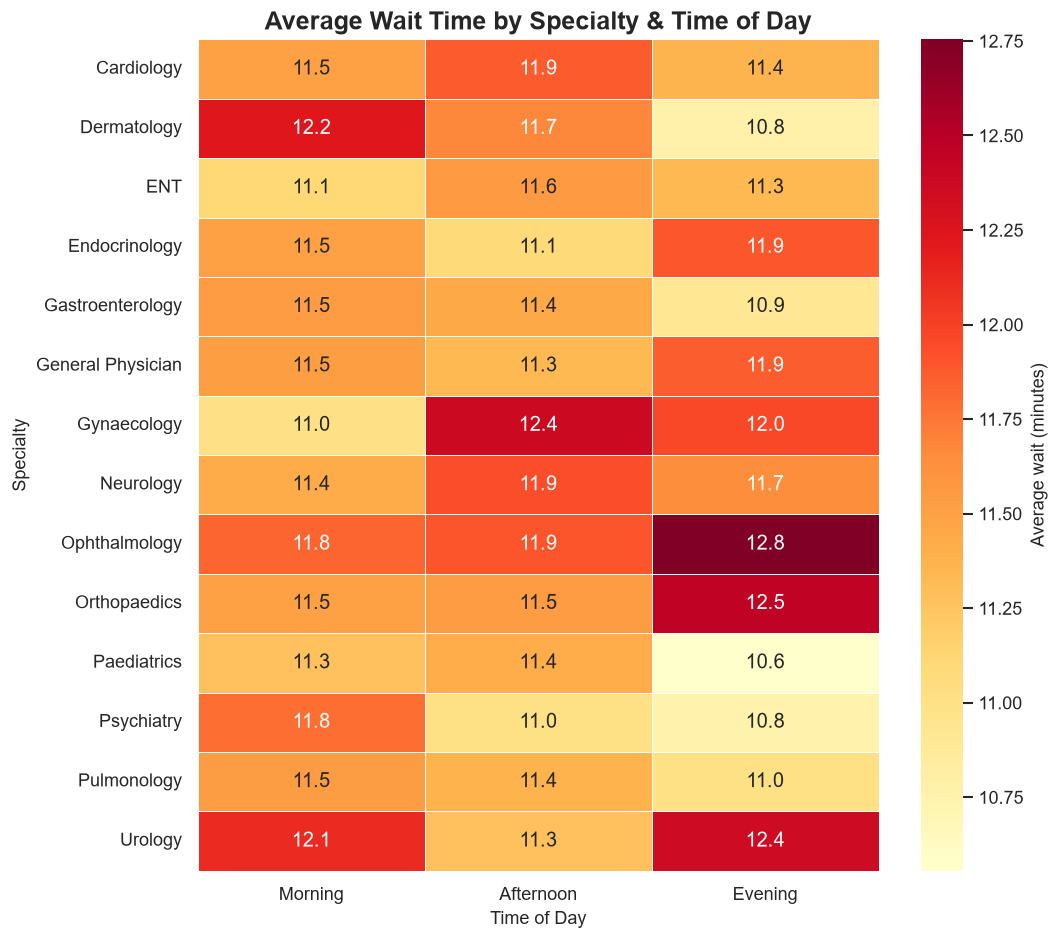

time_of_day,Morning,Afternoon,Evening
specialty,,,
Cardiology,11.50,11.90,11.40
Dermatology,12.20,11.70,10.80
ENT,11.10,11.60,11.30
Endocrinology,11.50,11.10,11.90
Gastroenterology,11.50,11.40,10.90
General Physician,11.50,11.30,11.90
Gynaecology,11.00,12.40,12.00
Neurology,11.40,11.90,11.70
Ophthalmology,11.80,11.90,12.80


In [37]:
time_order = ["Morning", "Afternoon", "Evening"]

wait_time_analysis = (
    completed.groupby(["specialty", "time_of_day"])
    .agg(avg_wait_time=("wait_time_minutes", "mean"))
    .reset_index()
)

wait_time_pivot = (
    wait_time_analysis.pivot(
        index="specialty",
        columns="time_of_day",
        values="avg_wait_time"
    )
    .reindex(columns=time_order)
)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    wait_time_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.4,
    cbar_kws={"label": "Average wait (minutes)"},
    ax=ax,
)
ax.set(title="Average Wait Time by Specialty & Time of Day", xlabel="Time of Day", ylabel="Specialty")
plt.tight_layout()
plt.show()

display(wait_time_pivot.round(1))

Pearson correlation: -0.004


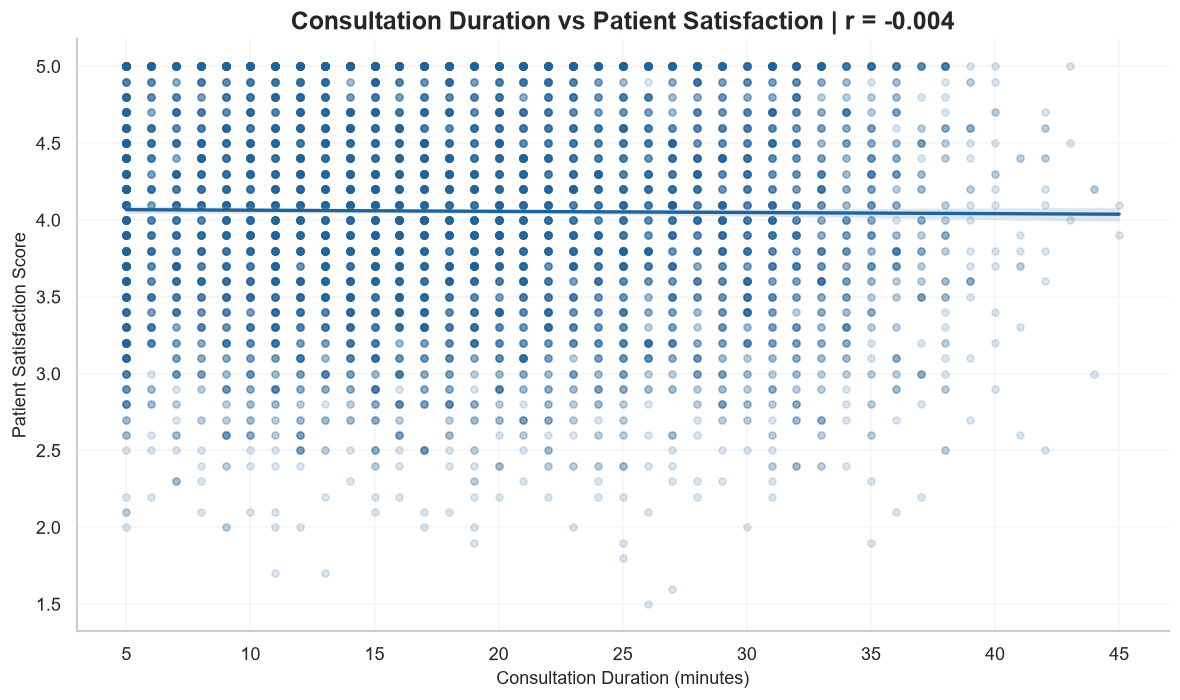

In [38]:
consultation_satisfaction = completed[[
    "consultation_duration_min",
    "patient_satisfaction_score",
]].dropna()

duration_satisfaction_corr = consultation_satisfaction.corr().iloc[0, 1]
print(f"Pearson correlation: {duration_satisfaction_corr:.3f}")

# Sample for a cleaner, faster portfolio chart while keeping the full-data correlation above.
sample_n = min(8000, len(consultation_satisfaction))
plot_sample = consultation_satisfaction.sample(sample_n, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=plot_sample,
    x="consultation_duration_min",
    y="patient_satisfaction_score",
    scatter_kws={"alpha": 0.16, "s": 18},
    line_kws={"linewidth": 2},
    color=BLUE,
    ax=ax,
)
ax.set(
    title=f"Consultation Duration vs Patient Satisfaction | r = {duration_satisfaction_corr:.3f}",
    xlabel="Consultation Duration (minutes)",
    ylabel="Patient Satisfaction Score",
)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

Doctors analysed: 320
Pearson correlation: 0.278


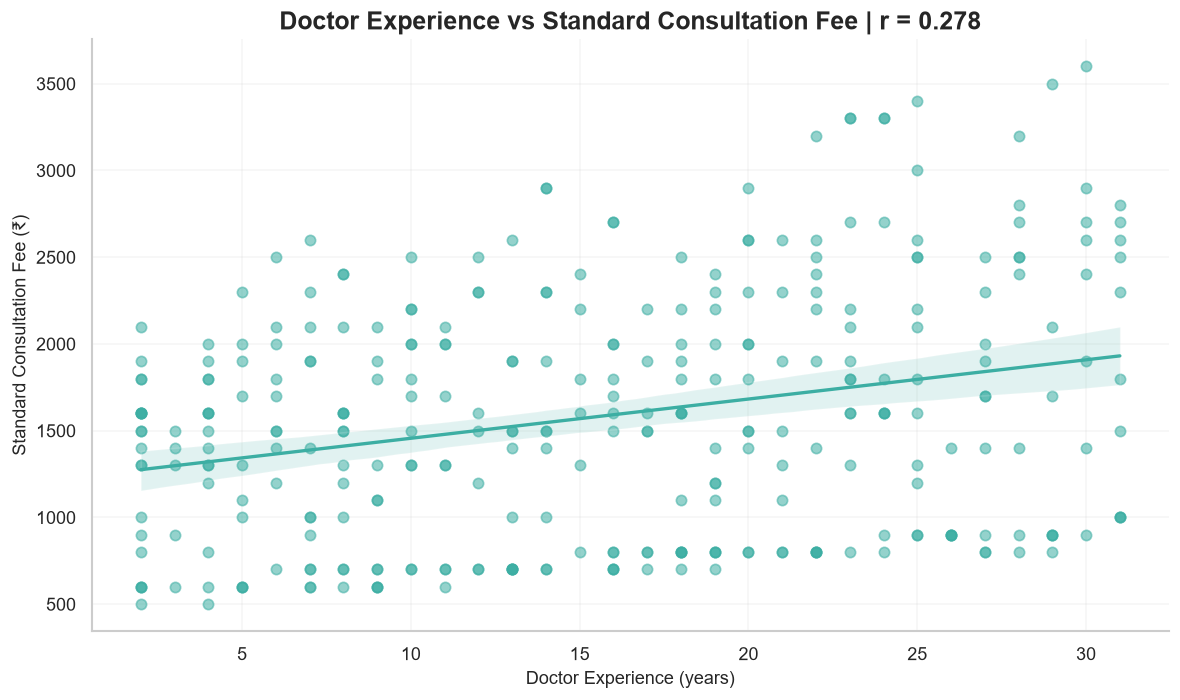

In [39]:
# Use one row per doctor to avoid appointment-level duplication and discount effects.
doctor_fee_analysis = doctors[[
    "doctor_id",
    "experience_years",
    "consultation_fee",
]].dropna().copy()

experience_fee_corr = doctor_fee_analysis[[
    "experience_years",
    "consultation_fee",
]].corr().iloc[0, 1]

print(f"Doctors analysed: {len(doctor_fee_analysis):,}")
print(f"Pearson correlation: {experience_fee_corr:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=doctor_fee_analysis,
    x="experience_years",
    y="consultation_fee",
    scatter_kws={"alpha": 0.55, "s": 38},
    line_kws={"linewidth": 2},
    color=TEAL,
    ax=ax,
)
ax.set(
    title=f"Doctor Experience vs Standard Consultation Fee | r = {experience_fee_corr:.3f}",
    xlabel="Doctor Experience (years)",
    ylabel="Standard Consultation Fee (₹)",
)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

## 8. Executive Findings & Recommendations
The code below generates the most important findings directly from the analysed data so the narrative stays consistent with the calculations.

In [40]:
highest_specialty = specialty_no_show.iloc[0]
lowest_specialty = specialty_no_show.iloc[-1]
highest_city = city_no_show.iloc[0]
lowest_city = city_no_show.iloc[-1]
highest_channel = booking_channel_no_show.iloc[0]
highest_type = appointment_type_no_show.iloc[0]
highest_time = time_no_show.sort_values("no_show_rate_pct", ascending=False).iloc[0]
best_reminder = reminder_analysis.sort_values("no_show_rate_pct").iloc[0]
top_revenue_city = city_revenue.iloc[0]

weekend_rate = day_type_no_show.loc[
    day_type_no_show["day_type"].eq("Weekend"), "no_show_rate_pct"
].iloc[0]
weekday_rate = day_type_no_show.loc[
    day_type_no_show["day_type"].eq("Weekday"), "no_show_rate_pct"
].iloc[0]

member_rates = membership_analysis.set_index("apollo_member")["no_show_rate_pct"]
repeat_rates = repeat_visit_analysis.set_index("repeat_visit")["no_show_rate_pct"]

print("KEY FINDINGS")
print("-" * 70)
print(f"1. Overall no-show rate: {overall_no_show_rate:.2f}%")
print(
    f"2. Highest-risk specialty: {highest_specialty['specialty']} "
    f"({highest_specialty['no_show_rate_pct']:.2f}%); "
    f"lowest: {lowest_specialty['specialty']} ({lowest_specialty['no_show_rate_pct']:.2f}%)."
)
print(
    f"3. Highest-risk city: {highest_city['city']} "
    f"({highest_city['no_show_rate_pct']:.2f}%); "
    f"lowest: {lowest_city['city']} ({lowest_city['no_show_rate_pct']:.2f}%)."
)
print(
    f"4. Highest-risk booking channel: {highest_channel['booking_channel']} "
    f"({highest_channel['no_show_rate_pct']:.2f}%)."
)
print(
    f"5. Highest-risk appointment type: {highest_type['appointment_type']} "
    f"({highest_type['no_show_rate_pct']:.2f}%)."
)
print(
    f"6. {highest_time['time_of_day']} slots have the highest observed time-of-day risk "
    f"({highest_time['no_show_rate_pct']:.2f}%)."
)
print(
    f"7. Weekend no-show rate is {weekend_rate:.2f}% vs {weekday_rate:.2f}% on weekdays."
)
print(
    f"8. Best observed reminder bundle: {best_reminder['reminder_type']} "
    f"({best_reminder['no_show_rate_pct']:.2f}% no-show rate), "
    f"a {best_reminder['pp_reduction_vs_no_reminder']:.2f} percentage-point "
    f"reduction vs no reminder."
)
print(
    f"9. Apollo members: {member_rates['Yes']:.2f}% vs non-members: {member_rates['No']:.2f}%."
)
print(
    f"10. Repeat patients: {repeat_rates['Yes']:.2f}% vs first-time patients: {repeat_rates['No']:.2f}%."
)
print(f"11. Estimated gross no-show fee exposure: {format_inr(no_show_fee_exposure)}.")
print(
    f"12. Highest realized-revenue city: {top_revenue_city['city']} "
    f"({format_inr(top_revenue_city['total_revenue'])})."
)
print(f"13. Duration vs satisfaction correlation: {duration_satisfaction_corr:.3f}.")
print(f"14. Doctor experience vs standard fee correlation: {experience_fee_corr:.3f}.")

KEY FINDINGS
----------------------------------------------------------------------
1. Overall no-show rate: 15.94%
2. Highest-risk specialty: Psychiatry (24.52%); lowest: Neurology (10.69%).
3. Highest-risk city: Lucknow (17.19%); lowest: Pune (13.30%).
4. Highest-risk booking channel: Walk-In (20.88%).
5. Highest-risk appointment type: Home Visit (26.25%).
6. Evening slots have the highest observed time-of-day risk (18.37%).
7. Weekend no-show rate is 18.68% vs 14.84% on weekdays.
8. Best observed reminder bundle: SMS + WhatsApp + Call (11.41% no-show rate), a 18.75 percentage-point reduction vs no reminder.
9. Apollo members: 12.66% vs non-members: 16.89%.
10. Repeat patients: 8.59% vs first-time patients: 66.78%.
11. Estimated gross no-show fee exposure: ₹1.97 Cr.
12. Highest realized-revenue city: Bengaluru (₹99.91 L).
13. Duration vs satisfaction correlation: -0.004.
14. Doctor experience vs standard fee correlation: 0.278.


In [41]:
print("BUSINESS RECOMMENDATIONS")
print("-" * 70)
print(
    f"• Prioritize confirmation workflows for {highest_type['appointment_type']} appointments, "
    f"{highest_channel['booking_channel']} bookings, and {highest_time['time_of_day'].lower()} slots."
)
print(
    f"• Use stronger reminder bundles for high-risk segments; "
    f"{best_reminder['reminder_type']} shows the lowest observed no-show rate."
)
print(
    f"• Add extra engagement for first-time patients and patients with prior no-shows, "
    f"because both segments show materially higher observed dropout."
)
print(
    f"• Focus local interventions first on {highest_city['city']} and high-risk specialties "
    f"such as {highest_specialty['specialty']}."
)
print(
    f"• Track the {format_inr(no_show_fee_exposure)} gross no-show fee exposure as a recurring KPI, "
    f"alongside realized revenue and completed appointments."
)
print(
    "• Continue monitoring wait time, utilisation, and satisfaction, but avoid assuming causation "
    "from descriptive correlations alone."
)

BUSINESS RECOMMENDATIONS
----------------------------------------------------------------------
• Prioritize confirmation workflows for Home Visit appointments, Walk-In bookings, and evening slots.
• Use stronger reminder bundles for high-risk segments; SMS + WhatsApp + Call shows the lowest observed no-show rate.
• Add extra engagement for first-time patients and patients with prior no-shows, because both segments show materially higher observed dropout.
• Focus local interventions first on Lucknow and high-risk specialties such as Psychiatry.
• Track the ₹1.97 Cr gross no-show fee exposure as a recurring KPI, alongside realized revenue and completed appointments.
• Continue monitoring wait time, utilisation, and satisfaction, but avoid assuming causation from descriptive correlations alone.


## 9. Final Notes

This is an **exploratory and descriptive** analysis. Observed differences (for example, reminders vs no reminder) show association and should not automatically be interpreted as causal effects without a controlled experiment or stronger causal design.

The notebook is intentionally structured around reusable functions, clear business scoping, and portfolio-ready visuals so it can be maintained and extended without duplicating calculations.

In [ ]:
import json
import base64
import io
from pathlib import Path
from PIL import Image

# Notebook file
notebook_path = Path("Apollo_Hospitals_EDA.ipynb")

# Output PDF
pdf_path = Path("Apollo_Hospitals_All_Charts.pdf")

# Read notebook
with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

chart_images = []

# Extract all PNG chart outputs
for cell in notebook["cells"]:
    if cell.get("cell_type") == "code":
        for output in cell.get("outputs", []):
            data = output.get("data", {})

            if "image/png" in data:
                image_data = base64.b64decode(data["image/png"])
                image = Image.open(io.BytesIO(image_data)).convert("RGB")
                chart_images.append(image.copy())

# Create multipage PDF
if chart_images:
    chart_images[0].save(
        pdf_path,
        save_all=True,
        append_images=chart_images[1:]
    )

    print(f"PDF created successfully: {pdf_path}")
    print(f"Total charts exported: {len(chart_images)}")
else:
    print("No chart outputs found. Please run and save the notebook first.")

PDF created successfully: Apollo_Hospitals_All_Charts.pdf
Total charts exported: 30
